# Final MAD baseline

In [40]:
from collections import defaultdict
from encodings.hex_codec import hex_encode
from itertools import combinations

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import polars.selectors as plselectors
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree

import social_groups.polars_columns as plc
from social_groups.analysis.defs.notebooks.definitions import register_materialization
from social_groups.analysis.notebook_assets import ExtraNotebookAsset
from social_groups.analysis.polars_transformations import (
    apply_parsing_and_group_decision,
)
from social_groups.analysis.polars_transformations.assert_suffix_cols_equal import (
    assert_suffix_cols_equal,
)
from social_groups.analysis.polars_transformations.deserialize_experiment_configuration import (
    deserialize_experiment_configuration,
)
from social_groups.analysis.polars_transformations.make_group_constellation import (
    parse_model_family,
    parse_parameters,
)
from social_groups.polars_values import MODEL_NAME_TO_LETTER_MAPPING
from social_groups.reporting.decision_scheme_comparison import (
    log_likelihood_of_decision_scheme,
    wasserstein_transition_distance_to_optimal,
)
from social_groups.reporting.group_decision_scheme import (
    calculate_decision_scheme_matrix,
    calculate_empirical_decision_scheme,
    calculate_empirical_decision_scheme_matrix,
    calculate_extended_decision_scheme,
)
from social_groups.reporting.group_reply import (
    GroupReplyAggregator,
    MajorityVote,
)
from social_groups.reporting.parsing import (
    AnswerComparer,
    AnswerOptions,
    AnswerParser,
)
from social_groups.reporting.plots.heterogeneous_group_composition_performance_against_baselines_plot import (
    heterogeneous_group_composition_performance_against_baselines_plot,
)
from social_groups.reporting.plots.improvement_per_family_constellation_heatmap_plot import (
    improvement_per_family_constellation_heatmap_plot,
)
from social_groups.reporting.plots.pareto_frontier_with_heterogeneous_points_plot import (
    pareto_frontier_with_heterogeneous_points_plot,
)
from social_groups.reporting.theoretical_decision_schemes import (
    THEORETICAL_DECISION_SCHEMES,
)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
parser = AnswerParser(AnswerOptions.letters_A_to_J)
group_reply = GroupReplyAggregator(MajorityVote())
comparer = AnswerComparer(
    AnswerOptions.letters_A_to_J, triple_underscore_handling="wrong"
)

In [3]:
from social_groups.analysis.definitions import defs

frame: pl.DataFrame = defs().load_asset_value("final_changed_order_mad")
baseline: pl.DataFrame = defs().load_asset_value("final_baseline")
no_discussion_baseline: pl.DataFrame = defs().load_asset_value(
    ["report", "final_no_discussion_voting", "all_group_combinations_majority_voting"]
)

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagster/_config/pythonic_config/typing_utils.py:101: UserWarning: Field name "extension" in "PolarsParquetIOManager" shadows an attribute in parent "BasePolarsUPathIOManager"
  return super().__new__(cls, name, bases, namespaces, **kwargs)
2026-06-13 21:42:25 +0200 - dagster - DEBUG - system - Loading file from: /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/final_changed_order_mad.parquet using PolarsParquetIOManager...
2026-06-13 21:42:28 +0200 - dagster - DEBUG - system - Loading file from: /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/final_baseline.parquet using PolarsParquetIOManager...
2026-06-13 21:42:28 +0200 - dagster - DEBUG - system - Loading file from: /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/report/final_no_discussion_voting/all

In [4]:
baseline_performance = (
    baseline.filter(pl.col("generation_method") == "standard")
    .filter(pl.col("with_few_shot_prompting") == True)
    .filter(pl.col("use_thinking") == True)
    .with_columns(
        comparer(parser(pl.col(plc.final_answer)), pl.col(plc.answer_string)).alias(
            plc.is_correct
        )
    )
    .group_by("model_name")
    .agg(
        pl.len(),
        pl.col(plc.is_correct).mean().alias(plc.accuracy),
        pl.col(plc.used_input_tokens).mean(),
        pl.col(plc.used_output_tokens).mean(),
    )
    .sort(plc.accuracy, descending=True)
    .with_columns(
        parse_model_family(pl.col("model_name")).alias(plc.model_family),
        pl.col("model_name")
        .replace(MODEL_NAME_TO_LETTER_MAPPING)
        .alias("model_letter"),
        call_cost_heuristic=parse_parameters(pl.col("model_name")) * 2,
    )
)

assert baseline_performance["len"].unique().item() == 1000

baseline_performance = baseline_performance.drop("len")

baseline_performance.head()

model_name,accuracy,used_input_tokens,used_output_tokens,model_family,model_letter,call_cost_heuristic
str,f64,f64,f64,str,str,f64
"""Qwen/Qwen3-14B""",0.733,1359.15,1466.703,"""Qwen3""","""H""",28.0
"""mistralai/Ministral-3-14B-Reas…",0.681,1346.492,502.132,"""Ministral""","""H""",28.0
"""Qwen/Qwen3.5-9B""",0.669,1390.333,2924.042,"""Qwen3.5""","""H""",18.0
"""mistralai/Ministral-3-8B-Reaso…",0.632,1346.492,570.057,"""Ministral""","""M""",16.0
"""Qwen/Qwen3-4B""",0.631,1359.15,1592.183,"""Qwen3""","""M""",8.0


In [5]:
num_rounds = (
    frame.with_columns(
        deserialize_experiment_configuration(pl.col("experiment_configuration_json"))
        .struct.field("strategy")
        .struct.field("configuration")
        .struct.field("number_of_rounds")
        .alias("number_of_rounds")
    )["number_of_rounds"]
    .unique()
    .item()
)

no_discussion_baseline = no_discussion_baseline.with_columns(
    call_cost_heuristic=pl.col("model_names")
    .list.eval(parse_parameters(pl.element()) * 2)
    .list.sum()
    * pl.col("no_participants")
    / pl.col("model_names").list.len()
).drop("model_names")
no_discussion_baseline.head()

family,group,no_participants,sizes,accuracy_mean,accuracy_std,used_input_tokens,used_output_tokens,call_cost_heuristic
str,str,i64,list[str],f64,f64,f64,f64,f64
"""Qwen3.5""","""LLM""",9,"[""L"", ""L"", ""M""]",0.493,0.008654,12551.997,18704.72925,33.6
"""Ministral""","""HHH""",6,"[""H"", ""H"", ""H""]",0.6839,0.003178,8096.952,3977.1975,168.0
"""Qwen3""","""LM""",12,"[""L"", ""M""]",0.6099,0.004932,16345.8,17937.97,55.2
"""Ministral""","""HH""",2,"[""H"", ""H""]",0.6409,0.00528,2698.984,1325.7325,56.0
"""Ministral""","""HM""",12,"[""H"", ""M""]",0.6579,0.003213,16193.904,7764.1895,264.0


In [6]:
mad_frame = apply_parsing_and_group_decision(frame, parser, comparer, group_reply)
mad_frame.head()

shape: (5, 33)
┌────────┬────────┬────────────┬────────────┬───┬────────────┬────────────┬────────────┬───────────┐
│ id     ┆ run_id ┆ message_id ┆ question_i ┆ … ┆ ___parsed_ ┆ ___parsed_ ┆ ___parsed_ ┆ is_correc │
│ ---    ┆ ---    ┆ s          ┆ d          ┆   ┆ individual ┆ combined_a ┆ combined_a ┆ t         │
│ i64    ┆ i64    ┆ ---        ┆ ---        ┆   ┆ _answers_a ┆ nswers_bef ┆ nswers_aft ┆ ---       │
│        ┆        ┆ list[i64]  ┆ i64        ┆   ┆ …          ┆ …          ┆ …          ┆ bool      │
│        ┆        ┆            ┆            ┆   ┆ ---        ┆ ---        ┆ ---        ┆           │
│        ┆        ┆            ┆            ┆   ┆ list[str]  ┆ str        ┆ str        ┆           │
╞════════╪════════╪════════════╪════════════╪═══╪════════════╪════════════╪════════════╪═══════════╡
│ 127500 ┆ 132    ┆ []         ┆ 152        ┆ … ┆ ["A", "A", ┆ A          ┆ A          ┆ true      │
│        ┆        ┆            ┆            ┆   ┆ "A"]       ┆            ┆            ┆           │
│ 127501 ┆ 132    ┆ []         ┆ 147        ┆ … ┆ ["A", "___ ┆ G          ┆ A          ┆ false     │
│        ┆        ┆            ┆            ┆   ┆ not_parsab ┆            ┆            ┆           │
│        ┆        ┆            ┆            ┆   ┆ le___",    ┆            ┆            ┆           │
│        ┆        ┆            ┆            ┆   ┆ "A…        ┆            ┆            ┆           │
│ 127502 ┆ 132    ┆ []         ┆ 111        ┆ … ┆ ["A", "A", ┆ A          ┆ A          ┆ true      │
│        ┆        ┆            ┆            ┆   ┆ "A"]       ┆            ┆            ┆           │
│ 127503 ┆ 132    ┆ []         ┆ 148        ┆ … ┆ ["F", "F", ┆ F          ┆ F          ┆ false     │
│        ┆        ┆            ┆            ┆   ┆ "F"]       ┆            ┆            ┆           │
│ 127504 ┆ 132    ┆ []         ┆ 292        ┆ … ┆ ["D", "D", ┆ D          ┆ D          ┆ false     │
│        ┆        ┆            ┆            ┆   ┆ "D"]       ┆            ┆            ┆           │
└────────┴────────┴────────────┴────────────┴───┴────────────┴────────────┴────────────┴───────────┘

In [7]:
frame2 = (
    mad_frame.group_by("model_family", plc.group_constellation)
    .agg(
        pl.len(),
        pl.col(plc.is_correct).mean().alias(plc.accuracy),
        pl.col(plc.used_input_tokens).mean(),
        pl.col(plc.used_output_tokens).mean(),
        pl.col("model_names").unique().item(),
        (
            pl.col("___parsed_individual_answers_after___").list.count_matches(
                "___not_parsable___"
            )
            / pl.col("___parsed_individual_answers_after___").list.len()
        )
        .mean()
        .alias("amount_parsing_errors_after"),
        (
            pl.col("___parsed_individual_answers_before___").list.count_matches(
                "___not_parsable___"
            )
            / pl.col("___parsed_individual_answers_before___").list.len()
        )
        .mean()
        .alias("amount_parsing_errors_before"),
    )
    .sort(plc.accuracy, descending=True)
    .with_row_index("row_id")
    .with_columns(
        pl.col("group_constellation")
        .map_elements(list, return_dtype=pl.List(pl.String))
        .list.sort()
        .alias("sizes"),
    )
    .with_columns(
        call_cost_heuristic=pl.col("model_names")
        .list.eval(parse_parameters(pl.element()) * 2 * num_rounds)
        .list.sum()
    )
)

best = (
    frame2.explode("sizes")
    .join(
        baseline_performance,
        left_on=["model_family", "sizes"],
        right_on=["model_family", "model_letter"],
        how="left",
        suffix="_best_individual_baseline",
    )
    .group_by("row_id")
    .agg(pl.all().sort_by("accuracy_best_individual_baseline").last())
)

best_no_discussion = (
    frame2.with_columns(num_llm_calls=pl.col("sizes").list.len() * num_rounds)
    .join(
        no_discussion_baseline.rename({"accuracy_mean": "accuracy"}).drop(
            "accuracy_std", "group"
        ),
        left_on=["model_family", "sizes", "num_llm_calls"],
        right_on=["family", "sizes", "no_participants"],
        how="left",
        suffix="_no_discussion_voting_same_calls_baseline",
    )
    .drop("num_llm_calls")
    .group_by("row_id")
    .agg(pl.all().sort_by("accuracy_no_discussion_voting_same_calls_baseline").last())
)

mad_performance = assert_suffix_cols_equal(frame2.join(best.drop("sizes"), on="row_id"))
mad_performance = assert_suffix_cols_equal(
    mad_performance.join(best_no_discussion, on="row_id").drop(["row_id", "sizes"])
)


assert mad_performance["len"].unique().item() == 1000
mad_performance = (
    mad_performance.drop("len")
    .drop("model_name")
    .with_columns(
        increase_from_individual=pl.col("accuracy")
        - pl.col("accuracy_best_individual_baseline"),
        increase_from_same_calls=pl.col("accuracy")
        - pl.col("accuracy_no_discussion_voting_same_calls_baseline"),
    )
    .with_columns(
        [
            (pl.col("used_input_tokens") / (pl.col("accuracy") * 100)).alias(
                "input_tokens_per_acc_pct"
            ),
            (pl.col("used_output_tokens") / (pl.col("accuracy") * 100)).alias(
                "output_tokens_per_acc_pct"
            ),
            (
                pl.col("used_input_tokens_best_individual_baseline")
                / (pl.col("accuracy_best_individual_baseline") * 100)
            ).alias("input_tokens_per_acc_pct_best_individual"),
            (
                pl.col("used_output_tokens_best_individual_baseline")
                / (pl.col("accuracy_best_individual_baseline") * 100)
            ).alias("output_tokens_per_acc_pct_best_individual"),
        ]
    )
    .with_columns(
        (pl.col("used_input_tokens") + pl.col("used_output_tokens")).alias(
            "used_total_tokens"
        ),
        (
            pl.col("used_input_tokens_best_individual_baseline")
            + pl.col("used_output_tokens_best_individual_baseline")
        ).alias("used_total_tokens_best_individual_baseline"),
        (
            pl.col("used_input_tokens_no_discussion_voting_same_calls_baseline")
            + pl.col("used_output_tokens_no_discussion_voting_same_calls_baseline")
        ).alias("used_total_tokens_no_discussion_voting_same_calls_baseline"),
    )
)

mad_performance.head()

model_family,group_constellation,accuracy,used_input_tokens,used_output_tokens,model_names,amount_parsing_errors_after,amount_parsing_errors_before,call_cost_heuristic,accuracy_best_individual_baseline,used_input_tokens_best_individual_baseline,used_output_tokens_best_individual_baseline,call_cost_heuristic_best_individual_baseline,accuracy_no_discussion_voting_same_calls_baseline,used_input_tokens_no_discussion_voting_same_calls_baseline,used_output_tokens_no_discussion_voting_same_calls_baseline,call_cost_heuristic_no_discussion_voting_same_calls_baseline,increase_from_individual,increase_from_same_calls,input_tokens_per_acc_pct,output_tokens_per_acc_pct,input_tokens_per_acc_pct_best_individual,output_tokens_per_acc_pct_best_individual,used_total_tokens,used_total_tokens_best_individual_baseline,used_total_tokens_no_discussion_voting_same_calls_baseline
str,str,f64,f64,f64,list[str],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Qwen3""","""MHH""",0.771,34322.547,8173.187,"[""Qwen/Qwen3-4B"", ""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B""]",0.018667,0.074667,192.0,0.733,1359.15,1466.703,28.0,0.7575,12259.35,12805.864,192.0,0.038,0.0135,445.169222,106.007613,18.542292,20.009591,42495.734,2825.853,25065.214
"""Qwen3""","""HMH""",0.767,34404.333,8279.762,"[""Qwen/Qwen3-14B"", ""Qwen/Qwen3-4B"", ""Qwen/Qwen3-14B""]",0.025,0.070667,192.0,0.733,1359.15,1466.703,28.0,0.7575,12259.35,12805.864,192.0,0.034,0.0095,448.557145,107.949961,18.542292,20.009591,42684.095,2825.853,25065.214
"""Qwen3""","""LHH""",0.766,34167.195,7903.707,"[""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B""]",0.024667,0.108,171.6,0.733,1359.15,1466.703,28.0,0.7529,12259.35,12651.525,171.6,0.033,0.0131,446.046932,103.181554,18.542292,20.009591,42070.902,2825.853,24910.875
"""Qwen3""","""HHH""",0.766,34570.127,8629.72,"[""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B""]",0.034,0.067333,252.0,0.733,1359.15,1466.703,28.0,0.7619,12259.35,12366.303,252.0,0.033,0.0041,451.307141,112.65953,18.542292,20.009591,43199.847,2825.853,24625.653
"""Qwen3""","""HLH""",0.76,34549.506,8033.723,"[""Qwen/Qwen3-14B"", ""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-14B""]",0.026333,0.109,171.6,0.733,1359.15,1466.703,28.0,0.7529,12259.35,12651.525,171.6,0.027,0.0071,454.598763,105.706882,18.542292,20.009591,42583.229,2825.853,24910.875


### Analyze Homogeneous MAD

In [8]:
homogeneous_mad = mad_performance.filter(
    pl.col("group_constellation").str.split("").list.unique().list.len() == pl.lit(1)
).with_columns(
    parameters=parse_parameters(pl.col("model_names").list.unique().list.item())
)

homogeneous_mad

model_family,group_constellation,accuracy,used_input_tokens,used_output_tokens,model_names,amount_parsing_errors_after,amount_parsing_errors_before,call_cost_heuristic,accuracy_best_individual_baseline,used_input_tokens_best_individual_baseline,used_output_tokens_best_individual_baseline,call_cost_heuristic_best_individual_baseline,accuracy_no_discussion_voting_same_calls_baseline,used_input_tokens_no_discussion_voting_same_calls_baseline,used_output_tokens_no_discussion_voting_same_calls_baseline,call_cost_heuristic_no_discussion_voting_same_calls_baseline,increase_from_individual,increase_from_same_calls,input_tokens_per_acc_pct,output_tokens_per_acc_pct,input_tokens_per_acc_pct_best_individual,output_tokens_per_acc_pct_best_individual,used_total_tokens,used_total_tokens_best_individual_baseline,used_total_tokens_no_discussion_voting_same_calls_baseline,parameters
str,str,f64,f64,f64,list[str],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Qwen3""","""HHH""",0.766,34570.127,8629.72,"[""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B""]",0.034,0.067333,252.0,0.733,1359.15,1466.703,28.0,0.7619,12259.35,12366.303,252.0,0.033,0.0041,451.307141,112.65953,18.542292,20.009591,43199.847,2825.853,24625.653,14.0
"""Qwen3""","""HH""",0.753,18252.437,5412.589,"[""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B""]",0.0285,0.0675,168.0,0.733,1359.15,1466.703,28.0,0.7517,8172.9,8244.202,168.0,0.02,0.0013,242.396242,71.880332,18.542292,20.009591,23665.026,2825.853,16417.102,14.0
"""Qwen3.5""","""HH""",0.69,40566.808,18629.895,"[""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-9B""]",0.14,0.1455,108.0,0.669,1390.333,2924.042,18.0,0.7286,8359.998,18399.4585,108.0,0.021,-0.0386,587.924754,269.998478,20.782257,43.707653,59196.703,4314.375,26759.4565,9.0
"""Qwen3.5""","""HHH""",0.688,81407.869,28992.94,"[""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-9B""]",0.167667,0.137667,162.0,0.669,1390.333,2924.042,18.0,0.7503,12539.997,27599.18775,162.0,0.019,-0.0623,1183.25391,421.409012,20.782257,43.707653,110400.809,4314.375,40139.18475,9.0
"""Ministral""","""HHH""",0.683,27854.907,5761.492,"[""mistralai/Ministral-3-14B-Reasoning-2512"", ""mistralai/Ministral-3-14B-Reasoning-2512"", ""mistralai/Ministral-3-14B-Reasoning-2512""]",0.027667,0.050333,252.0,0.681,1346.492,502.132,28.0,0.6981,12145.428,5965.79625,252.0,0.002,-0.0151,407.831728,84.355666,19.772276,7.373451,33616.399,1848.624,18111.22425,14.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Ministral""","""LLL""",0.393,28106.961,5907.657,"[""mistralai/Ministral-3-3B-Reasoning-2512"", ""mistralai/Ministral-3-3B-Reasoning-2512"", ""mistralai/Ministral-3-3B-Reasoning-2512""]",0.112,0.114,54.0,0.436,1346.492,291.833,6.0,0.4281,12145.428,5783.937,54.0,-0.043,-0.0351,715.189847,150.322061,30.882844,6.693417,34014.618,1638.325,17929.365,3.0
"""Qwen3""","""LLL""",0.304,36776.233,8532.898,"[""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-0.6B""]",0.044,0.197667,10.8,0.314,1359.15,1553.256,1.2,0.2978,12259.35,13221.969,10.8,-0.01,0.0062,1209.744507,280.687434,43.285032,49.466752,45309.131,2912.406,25481.319,0.6
"""Qwen3.5""","""LLL""",0.279,52258.947,15691.357,"[""Qwen/Qwen3.5-0.8B"", ""Qwen/Qwen3.5-0.8B"", ""Qwen/Qwen3.5-0.8B""]",0.357333,0.314,14.4,0.145,1390.333,3952.648,1.6,0.3372,12557.997,13532.1945,14.4,0.134,-0.0582,1873.080538,562.414229,95.885034,272.596414,67950.304,5342.981,26090.1915,0.8


In [9]:
main_results_homog_mad_formatted = (
    homogeneous_mad.select(
        "model_family",
        "group_constellation",
        "accuracy",
        "accuracy_no_discussion_voting_same_calls_baseline",
        "accuracy_best_individual_baseline",
        "amount_parsing_errors_after",
    )
    .sort("accuracy", descending=True)
    .with_columns(
        [
            pl.col("accuracy").map_elements(
                lambda x: f"{x:.3f}", return_dtype=pl.String
            ),
            pl.col("amount_parsing_errors_after").map_elements(
                lambda x: f"{x * 100:.0f}%", return_dtype=pl.String
            ),
        ]
        + [
            pl.struct(["accuracy", col])
            .map_elements(
                lambda r, c=col: f"{r[c]:.3f} ({r['accuracy'] - r[c]:+.3f})",
                return_dtype=pl.String,
            )
            .alias(col)
            for col in homogeneous_mad.columns
            if col.startswith("accuracy_")
        ]
    )
    .rename(
        {
            "model_family": "Model Family",
            "group_constellation": "Group Const.",
            "accuracy": "MAD Accuracy",
            "accuracy_no_discussion_voting_same_calls_baseline": "<Voting> Baseline",
            "accuracy_best_individual_baseline": "<Best Indiv.> Baseline",
            "amount_parsing_errors_after": "Invalid Answers",
        }
    )
)

register_materialization(
    "main_results_homog_mad_formatted",
    main_results_homog_mad_formatted,
    "Main Results for homogeneous MAD",
    force=True,
)

main_results_homog_mad_formatted

Wrote to:  /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/report/final_mad_baseline/main_results_homog_mad_formatted.tex


/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(


Model Family,Group Const.,MAD Accuracy,<Voting> Baseline,<Best Indiv.> Baseline,Invalid Answers
str,str,str,str,str,str
"""Qwen3""","""HHH""","""0.766""","""0.762 (+0.004)""","""0.733 (+0.033)""","""3%"""
"""Qwen3""","""HH""","""0.753""","""0.752 (+0.001)""","""0.733 (+0.020)""","""3%"""
"""Qwen3.5""","""HH""","""0.690""","""0.729 (-0.039)""","""0.669 (+0.021)""","""14%"""
"""Qwen3.5""","""HHH""","""0.688""","""0.750 (-0.062)""","""0.669 (+0.019)""","""17%"""
"""Ministral""","""HHH""","""0.683""","""0.698 (-0.015)""","""0.681 (+0.002)""","""3%"""
…,…,…,…,…,…
"""Ministral""","""LLL""","""0.393""","""0.428 (-0.035)""","""0.436 (-0.043)""","""11%"""
"""Qwen3""","""LLL""","""0.304""","""0.298 (+0.006)""","""0.314 (-0.010)""","""4%"""
"""Qwen3.5""","""LLL""","""0.279""","""0.337 (-0.058)""","""0.145 (+0.134)""","""36%"""


In [10]:
main_results_homog_mad_formatted.select(
    pl.corr(
        "MAD Accuracy",
        "<Voting> Baseline",
        method="spearman",
    ).alias("mad_vs_voting"),
    pl.corr(
        "MAD Accuracy",
        "<Best Indiv.> Baseline",
        method="spearman",
    ).alias("mad_vs_best"),
    pl.corr(
        "<Voting> Baseline",
        "<Best Indiv.> Baseline",
        method="spearman",
    ).alias("voting_vs_best"),
)

mad_vs_voting,mad_vs_best,voting_vs_best
f64,f64,f64
0.967476,0.904492,0.836945


Wrote to:  /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/report/final_mad_baseline/improvement_per_family_constellation_heatmap_plot_homogeneous_mad.png


/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(


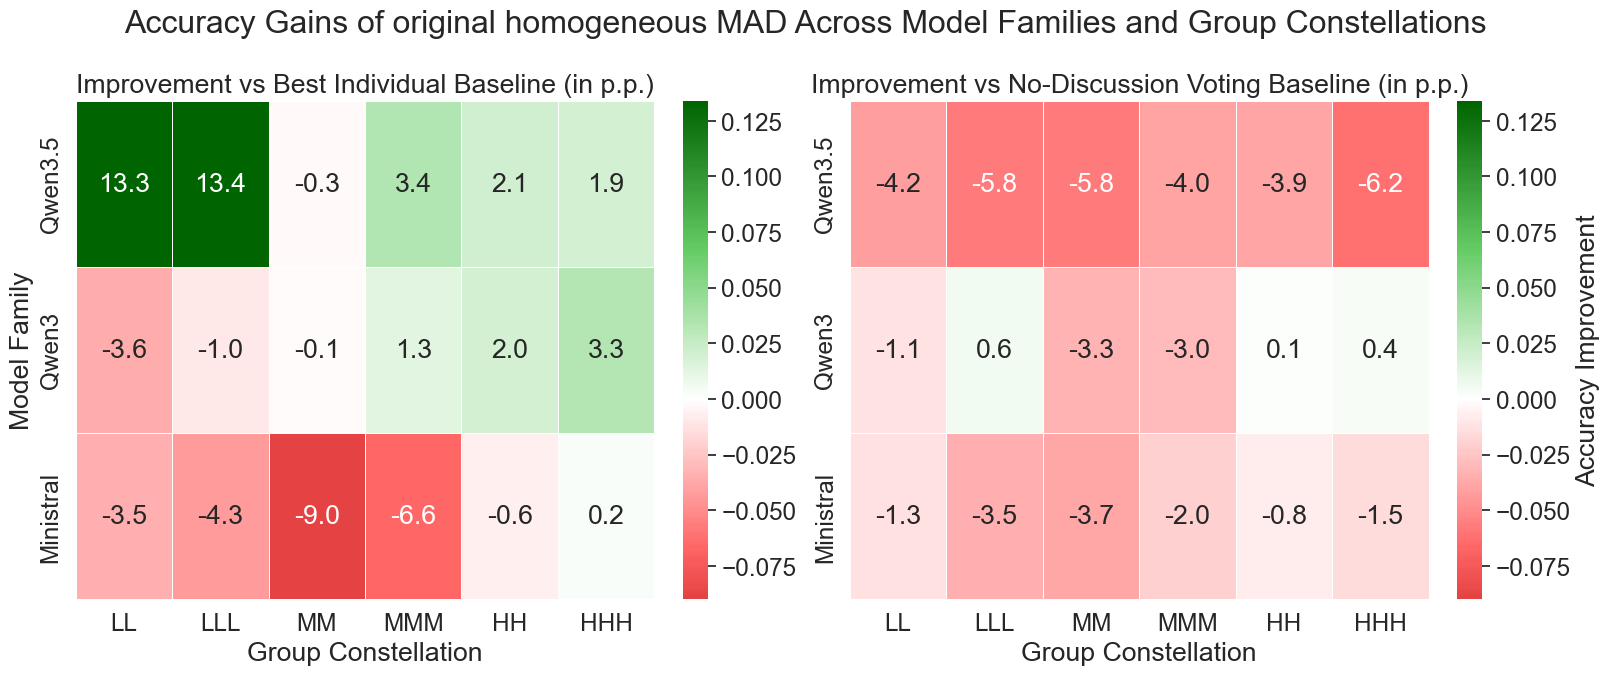

In [11]:
register_materialization(
    "improvement_per_family_constellation_heatmap_plot_homogeneous_mad",
    improvement_per_family_constellation_heatmap_plot(
        homogeneous_mad.with_columns(
            [
                (
                    pl.col("accuracy") - pl.col("accuracy_best_individual_baseline")
                ).alias("Best Individual Baseline"),
                (
                    pl.col("accuracy")
                    - pl.col("accuracy_no_discussion_voting_same_calls_baseline")
                ).alias("No-Discussion Voting Baseline"),
            ]
        ),
        ["Best Individual Baseline", "No-Discussion Voting Baseline"],
        "Accuracy Gains of original homogeneous MAD Across Model Families and Group Constellations",
    ),
    "Improvement compared to baselines of homogeneous MAD.",
    force=True,
)
print("")

<Axes: >

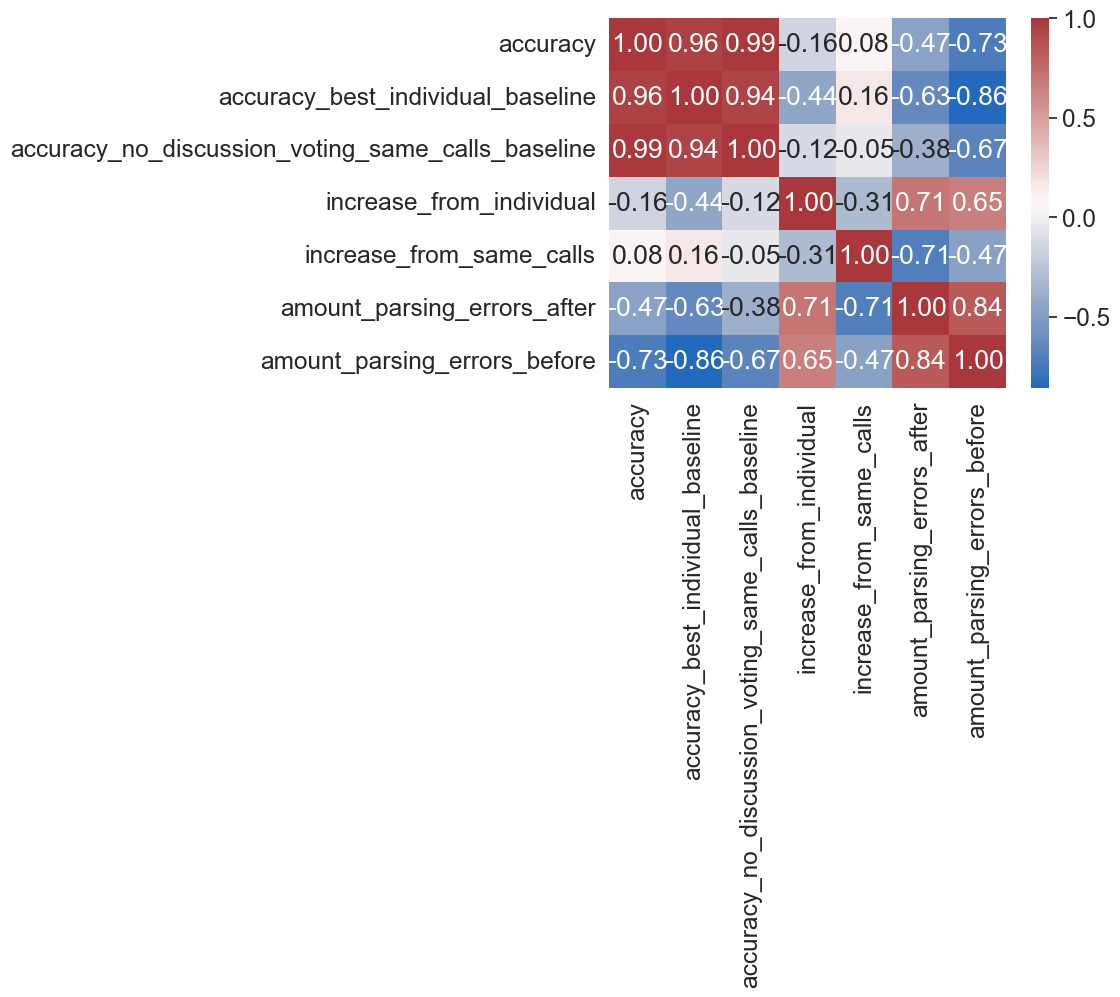

In [12]:
tmp = (
    homogeneous_mad.select(
        pl.selectors.starts_with("accuracy"),
        pl.selectors.starts_with("increase"),
        "amount_parsing_errors_after",
        "amount_parsing_errors_before",
    )
    .corr()
    .to_pandas()
)
tmp.index = tmp.columns
sns.heatmap(tmp, cmap="vlag", annot=True, fmt=".2f")

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(


Wrote to:  /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/report/final_mad_baseline/homogeneous_mad_cost_tradeoff_paretofront_plot.png


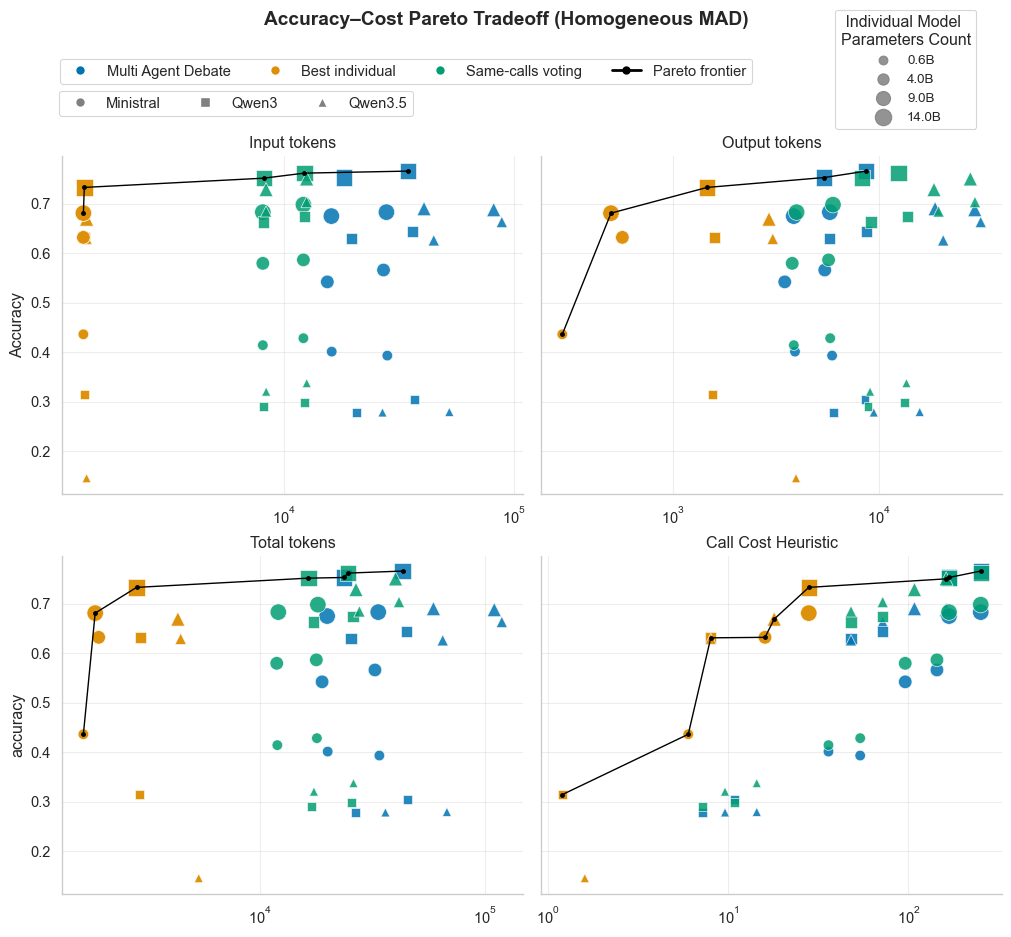

In [13]:
from social_groups.reporting.plots.homogeneous_mad_cost_tradeoff_paretofront_plot import (
    homogeneous_mad_cost_tradeoff_paretofront_plot,
)

register_materialization(
    "homogeneous_mad_cost_tradeoff_paretofront_plot",
    homogeneous_mad_cost_tradeoff_paretofront_plot(homogeneous_mad),
    "Cost Tradeoff comparing MAD, Single-Model Baseline, and Same-#LLM-Calls Voting baseline using input, output, total tokens, and call-cost heuristic.",
    force=True,
)

## Assert that all groups are monotonically increasing


In [14]:
# sort first so rows are in participant order within each group

df_sorted = no_discussion_baseline.sort(["family", "group", "sizes", "no_participants"])

# check monotonicity inside each group

violations = df_sorted.with_columns(
    prev_accuracy=pl.col("accuracy_mean").shift(1).over(["family", "group", "sizes"])
).filter(
    pl.col("prev_accuracy").is_not_null()
    & (pl.col("accuracy_mean") < pl.col("prev_accuracy") - 0.01)
)

assert violations.is_empty(), (
    "accuracy_mean is not monotonically increasing with no_participants"
)

## Analyze Heterogeneous MAD

In [15]:
heterogeneous_mad = mad_performance.filter(
    pl.col("group_constellation").str.split("").list.unique().list.len() != pl.lit(1)
)
heterogeneous_mad

model_family,group_constellation,accuracy,used_input_tokens,used_output_tokens,model_names,amount_parsing_errors_after,amount_parsing_errors_before,call_cost_heuristic,accuracy_best_individual_baseline,used_input_tokens_best_individual_baseline,used_output_tokens_best_individual_baseline,call_cost_heuristic_best_individual_baseline,accuracy_no_discussion_voting_same_calls_baseline,used_input_tokens_no_discussion_voting_same_calls_baseline,used_output_tokens_no_discussion_voting_same_calls_baseline,call_cost_heuristic_no_discussion_voting_same_calls_baseline,increase_from_individual,increase_from_same_calls,input_tokens_per_acc_pct,output_tokens_per_acc_pct,input_tokens_per_acc_pct_best_individual,output_tokens_per_acc_pct_best_individual,used_total_tokens,used_total_tokens_best_individual_baseline,used_total_tokens_no_discussion_voting_same_calls_baseline
str,str,f64,f64,f64,list[str],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Qwen3""","""MHH""",0.771,34322.547,8173.187,"[""Qwen/Qwen3-4B"", ""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B""]",0.018667,0.074667,192.0,0.733,1359.15,1466.703,28.0,0.7575,12259.35,12805.864,192.0,0.038,0.0135,445.169222,106.007613,18.542292,20.009591,42495.734,2825.853,25065.214
"""Qwen3""","""HMH""",0.767,34404.333,8279.762,"[""Qwen/Qwen3-14B"", ""Qwen/Qwen3-4B"", ""Qwen/Qwen3-14B""]",0.025,0.070667,192.0,0.733,1359.15,1466.703,28.0,0.7575,12259.35,12805.864,192.0,0.034,0.0095,448.557145,107.949961,18.542292,20.009591,42684.095,2825.853,25065.214
"""Qwen3""","""LHH""",0.766,34167.195,7903.707,"[""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B""]",0.024667,0.108,171.6,0.733,1359.15,1466.703,28.0,0.7529,12259.35,12651.525,171.6,0.033,0.0131,446.046932,103.181554,18.542292,20.009591,42070.902,2825.853,24910.875
"""Qwen3""","""HLH""",0.76,34549.506,8033.723,"[""Qwen/Qwen3-14B"", ""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-14B""]",0.026333,0.109,171.6,0.733,1359.15,1466.703,28.0,0.7529,12259.35,12651.525,171.6,0.027,0.0071,454.598763,105.706882,18.542292,20.009591,42583.229,2825.853,24910.875
"""Qwen3""","""LMH""",0.755,34214.715,7645.442,"[""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-4B"", ""Qwen/Qwen3-14B""]",0.019,0.114,111.6,0.733,1359.15,1466.703,28.0,0.7015,12259.35,13091.086,111.6,0.022,0.0535,453.175033,101.264132,18.542292,20.009591,41860.157,2825.853,25350.436
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Ministral""","""MLL""",0.507,27962.005,5817.647,"[""mistralai/Ministral-3-8B-Reasoning-2512"", ""mistralai/Ministral-3-3B-Reasoning-2512"", ""mistralai/Ministral-3-3B-Reasoning-2512""]",0.143,0.107333,84.0,0.632,1346.492,570.057,16.0,0.4769,12145.428,5749.454,84.0,-0.125,0.0301,551.518836,114.746489,21.305253,9.019889,33779.652,1916.549,17894.882
"""Qwen3""","""LML""",0.478,36780.475,8653.899,"[""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-4B"", ""Qwen/Qwen3-0.6B""]",0.034667,0.159,31.2,0.631,1359.15,1592.183,8.0,0.4535,12259.35,13376.308,31.2,-0.153,0.0245,769.466004,181.043912,21.53962,25.232694,45434.374,2951.333,25635.658
"""Qwen3""","""ML""",0.47,20446.808,6023.639,"[""Qwen/Qwen3-4B"", ""Qwen/Qwen3-0.6B""]",0.043,0.1515,27.6,0.631,1359.15,1592.183,8.0,0.554,8172.9,8968.985,27.6,-0.161,-0.084,435.038468,128.162532,21.53962,25.232694,26470.447,2951.333,17141.885


### Correlation between Ranks of group_constellations per family:

In [51]:
import polars as pl
from itertools import combinations_with_replacement
from scipy.stats import kendalltau, spearmanrho
import numpy as np

rank_df = (
    heterogeneous_mad.with_columns(
        pl.col("accuracy")
        .rank(descending=True)
        .over("model_family")
        .alias("accuracy_rank")
        .cast(pl.Int64)
    )
    .group_by("group_constellation", "model_family")
    .agg(pl.col("accuracy_rank").item())
    .sort("accuracy_rank")
    .pivot(
        on="model_family",
        index="group_constellation",
        values="accuracy_rank",
    )
)

families = rank_df.select(pl.selectors.exclude("group_constellation")).columns

# Compute Spearman rho matrix

rho_matrix = np.eye(len(families))

for i, a in enumerate(families):
    for j, b in enumerate(families[i + 1 :], start=i + 1):
        rho, _ = spearmanrho(
            rank_df[a].to_numpy(),
            rank_df[b].to_numpy(),
        )

        rho_matrix[i, j] = rho

        rho_matrix[j, i] = rho

# Nice Polars DataFrame

rho_df = pl.DataFrame(
    {
        "Model Family": families,
        **{family: rho_matrix[:, idx] for idx, family in enumerate(families)},
    }
)
register_materialization(
    "rho_matrix_group_constellation_correlation",
    rho_df,
    "Spearman Rank correlation for the Performance ordering of different group constellations for different families.",
    force=True,
)

rho_df

Wrote to:  /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/report/final_mad_baseline/rho_matrix_group_constellation_correlation.tex


/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(


Model Family,Ministral,Qwen3.5,Qwen3
str,f64,f64,f64
"""Ministral""",1.0,0.746385,0.904439
"""Qwen3.5""",0.746385,1.0,0.829458
"""Qwen3""",0.904439,0.829458,1.0


In [157]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib import colors as mcolors


# -----------------------------
# 1. Prepare data
# -----------------------------

plot_df = (
    heterogeneous_mad.with_columns(
        pl.col("group_constellation")
        .map_elements(lambda s: "".join(sorted(s)), return_dtype=pl.String)
        .alias("group_composition")
    )
    .group_by("group_composition", "model_family")
    .agg(
        pl.col("accuracy").implode(),
        pl.col("group_constellation").implode(),
        pl.col("accuracy_no_discussion_voting_same_calls_baseline").unique().item(),
        pl.col("accuracy_best_individual_baseline").unique().item(),
        pl.col("call_cost_heuristic_no_discussion_voting_same_calls_baseline")
        .unique()
        .item(),
    )
)

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(


Wrote to:  /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/report/final_mad_baseline/heterogeneous_group_composition_performance_against_baselines.png


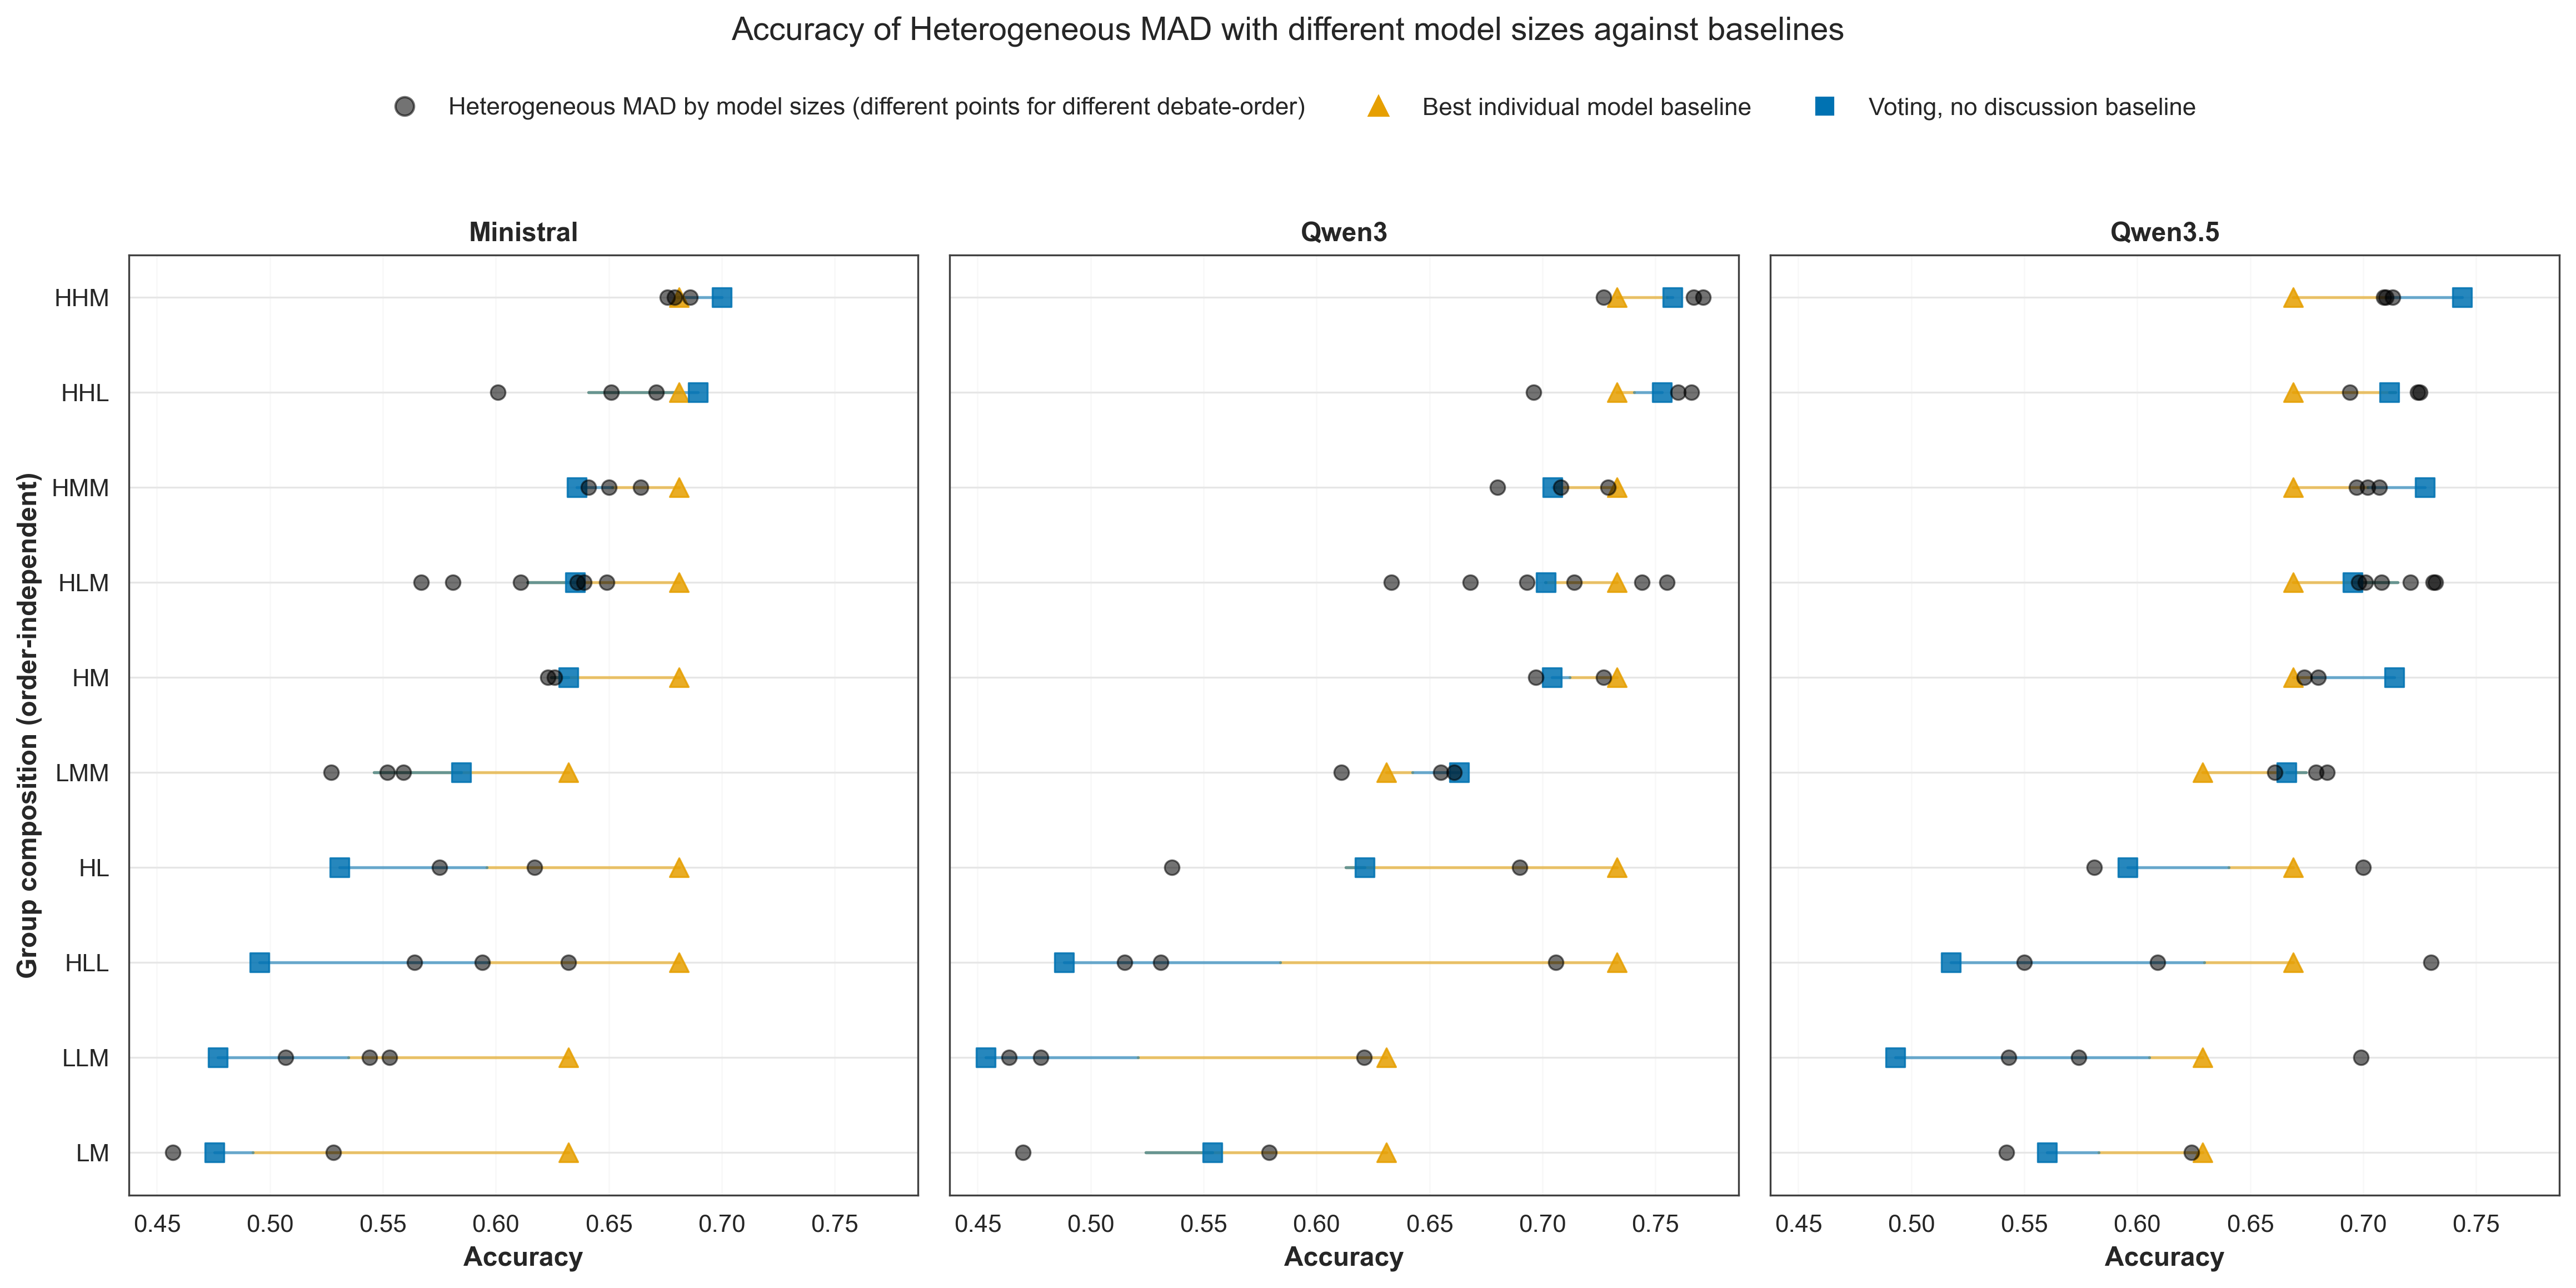

In [158]:
register_materialization(
    "heterogeneous_group_composition_performance_against_baselines",
    heterogeneous_group_composition_performance_against_baselines_plot(plot_df),
    "Accuracy of heterogeneous MAD based on model-sizes against baseline for different group compositions and debate orders",
    force=True,
)

In [306]:
enhanced_plot_df = (
    plot_df.filter(
        pl.col("group_composition").str.split("").list.unique().list.len() != 1
    )
    .with_columns(
        (pl.col("accuracy") - pl.col("accuracy_best_individual_baseline")).alias(
            "increase_from_best_individual_baseline"
        ),
        (
            pl.col("accuracy")
            - pl.col("accuracy_no_discussion_voting_same_calls_baseline")
        ).alias("increase_from_no_discussion_voting_same_calls_baseline"),
        pl.col("accuracy").list.arg_max().alias("arg_max"),
    )
    .with_columns(
        pl.col("group_constellation")
        .list.get(pl.col("arg_max"))
        .alias("best_constellation"),
        pl.col("accuracy").list.get(pl.col("arg_max")).alias("best_accuracy"),
        # pl.col("accuracy").list.std().alias("accuracy_std_dev_over_constellations"),
        pl.col("accuracy").list.min().alias("worst_accuracy"),
    )
    .with_columns(
        pl.when(pl.col("worst_accuracy") == pl.col("best_accuracy"))
        .then(pl.lit(None))
        .otherwise(pl.col("worst_accuracy"))
        .alias("worst_accuracy")
        # pl.col("accuracy").list.set_difference(pl.col("best_accuracy").cast(pl.List(pl.Float64))).alias("other_accuracies")
    )
    .drop("arg_max", "group_constellation")
)


better_thanbaseline_result = (
    (
        enhanced_plot_df.filter(
            pl.all_horizontal(
                pl.selectors.starts_with("increase")
                .list.eval(pl.element().gt(0.0))
                .list.any()
            )
        )
        .drop(pl.selectors.starts_with("increase"), "accuracy")
        .rename(
            {
                "group_composition": "Group (Unordered)",
                "model_family": "Model Family",
                "accuracy_no_discussion_voting_same_calls_baseline": "Majority-Vote Baseline Accuracy",
                "accuracy_best_individual_baseline": "Best Individual Model Accuracy",
                "best_constellation": "Optimal Model Constellation",
                "best_accuracy": "Optimal Constellation Accuracy",
                "worst_accuracy": "Worst Constellation Accuracy",
            }
        )
        .select(
            [
                "Group (Unordered)",
                "Model Family",
                "Optimal Model Constellation",
                "Optimal Constellation Accuracy",
                "Worst Constellation Accuracy",
                "Majority-Vote Baseline Accuracy",
                "Best Individual Model Accuracy",
                "call_cost_heuristic_no_discussion_voting_same_calls_baseline",
            ]
        )
    )
    .sort("Best Individual Model Accuracy", descending=True)
    .with_columns(
        pl.selectors.numeric().map_elements(
            lambda x: f"{round(x, 2):.2f}",
            return_dtype=pl.String,
        )
    )
    .fill_null(" - ")
    .with_columns(
        (
            pl.col("Optimal Constellation Accuracy")
            + pl.lit("|")
            + pl.col("Worst Constellation Accuracy")
        ).alias("Constellation Acc. (Optimal|Worst)"),
        (
            pl.col("Majority-Vote Baseline Accuracy")
            + pl.lit("|")
            + pl.col("Best Individual Model Accuracy")
        ).alias("Baseline (Voting|Individual)"),
    )
    .drop(
        "call_cost_heuristic_no_discussion_voting_same_calls_baseline",
        "Majority-Vote Baseline Accuracy",
        "Best Individual Model Accuracy",
        "Worst Constellation Accuracy",
        "Optimal Constellation Accuracy",
    )
)

register_materialization(
    "mode_compositions_that_can_be_better_than_baselines",
    better_thanbaseline_result,
    "Table of Model Compositions that can be better than both single model and no discussion baseline.",
    force=True,
)

better_thanbaseline_result

Wrote to:  /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/report/final_mad_baseline/mode_compositions_that_can_be_better_than_baselines.tex


/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(


Group (Unordered),Model Family,Optimal Model Constellation,Constellation Acc. (Optimal|Worst),Baseline (Voting|Individual)
str,str,str,str,str
"""HLM""","""Qwen3""","""LMH""","""0.76|0.63""","""0.70|0.73"""
"""HHL""","""Qwen3""","""LHH""","""0.77|0.70""","""0.75|0.73"""
"""HHM""","""Qwen3""","""MHH""","""0.77|0.73""","""0.76|0.73"""
"""HLM""","""Qwen3.5""","""HLM""","""0.73|0.70""","""0.70|0.67"""
"""HHL""","""Qwen3.5""","""LHH""","""0.72|0.69""","""0.71|0.67"""
"""HLL""","""Qwen3.5""","""LLH""","""0.73|0.55""","""0.52|0.67"""
"""HL""","""Qwen3.5""","""LH""","""0.70|0.58""","""0.60|0.67"""
"""LMM""","""Qwen3.5""","""MLM""","""0.68|0.66""","""0.67|0.63"""
"""LLM""","""Qwen3.5""","""LLM""","""0.70|0.54""","""0.49|0.63"""


In [308]:
spread_df = (
    enhanced_plot_df.with_columns(
        spread=pl.col("best_accuracy") - pl.col("worst_accuracy")
    )
    .pivot(index="group_composition", on="model_family", values="spread")
    .rename({"group_composition": "Group Composition"})
    .with_columns(Average=pl.mean_horizontal(pl.selectors.numeric()))
    .with_columns(pl.selectors.numeric().round(2))
    .sort("Average", descending=True)
)


register_materialization(
    "accuracy_spread_by_group_ordering_per_composition",
    spread_df,
    "Table of Model Compositions that can be better than both single model and no discussion baseline.",
    force=True,
)

spread_df

Wrote to:  /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/report/final_mad_baseline/accuracy_spread_by_group_ordering_per_composition.tex


/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(


Group Composition,Qwen3,Qwen3.5,Ministral,Average
str,f64,f64,f64,f64
"""HLL""",0.19,0.18,0.07,0.15
"""LLM""",0.16,0.16,0.05,0.12
"""HL""",0.15,0.12,0.04,0.1
"""LM""",0.11,0.08,0.07,0.09
"""HLM""",0.12,0.03,0.08,0.08
"""HHL""",0.07,0.03,0.07,0.06
"""LMM""",0.05,0.02,0.03,0.04
"""HMM""",0.05,0.01,0.02,0.03
"""HHM""",0.04,0.0,0.01,0.02


/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(


Wrote to:  /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/report/final_mad_baseline/baseline_pareto_frontiers_with_heterogeneous_points.png


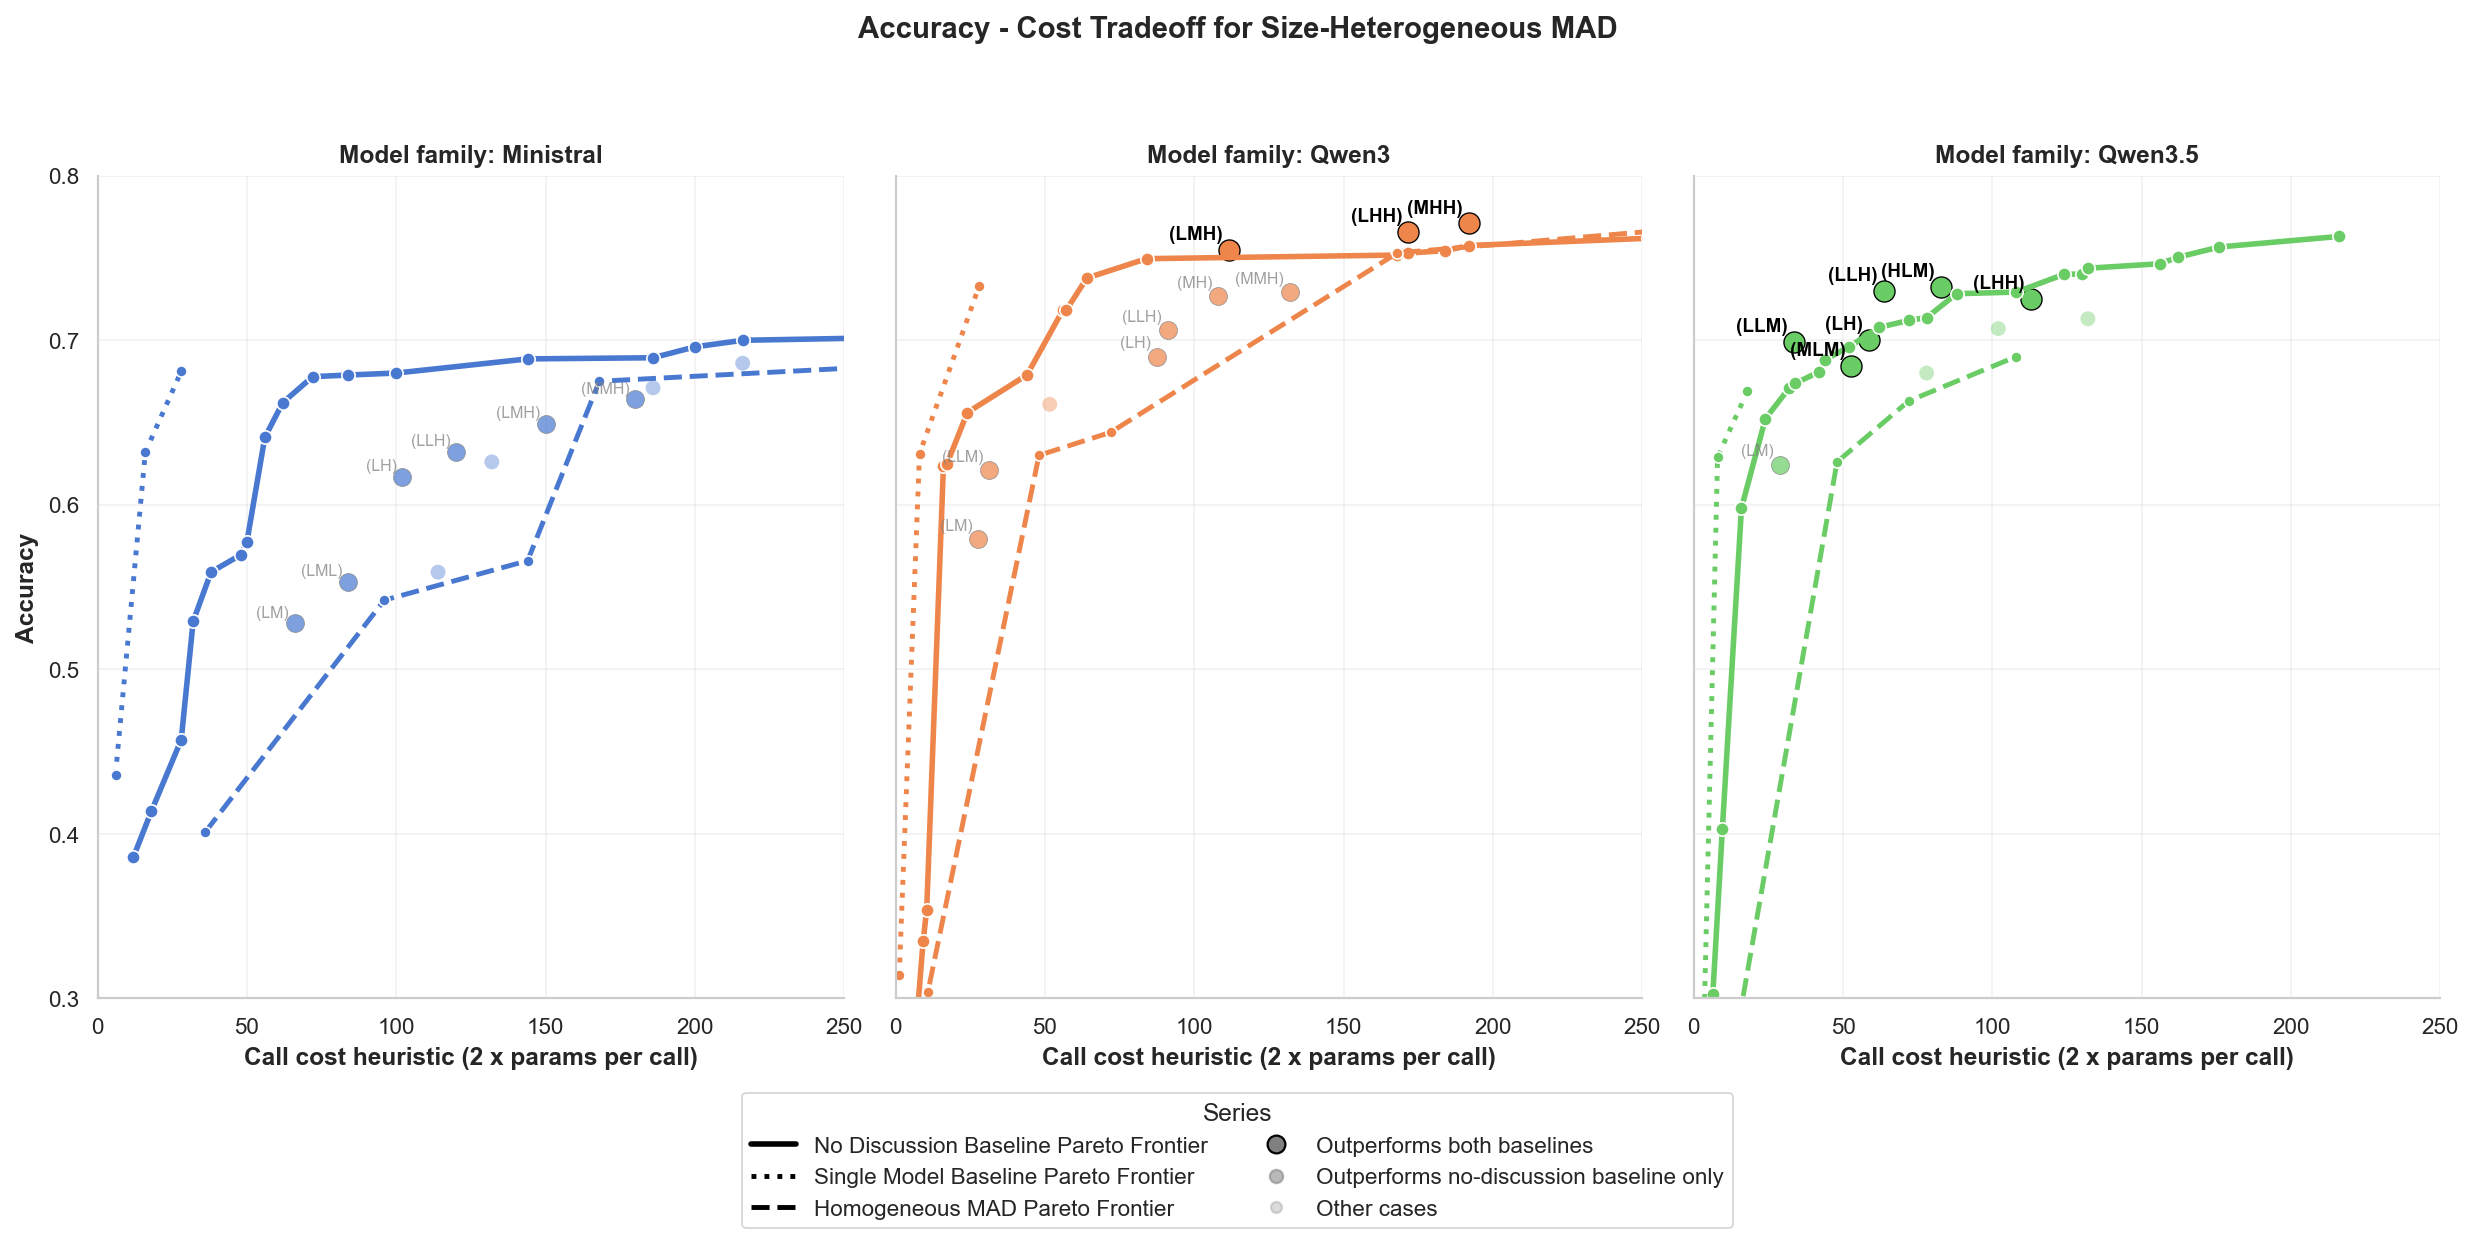

In [204]:
register_materialization(
    "baseline_pareto_frontiers_with_heterogeneous_points",
    pareto_frontier_with_heterogeneous_points_plot(
        no_discussion_baseline, baseline_performance, enhanced_plot_df, homogeneous_mad
    ),
    "Accuracy Cost Pareto Frontier by Model family compared with heterogeneous MAD instances that beat both baselines. ",
    force=True,
)

### Decision Scheme Analysis

#### For One Case:

In [205]:
one_case_data = mad_frame.filter(pl.col("run_id") == 132)

print("Extended Decision Scheme Data:")
print(
    calculate_extended_decision_scheme(
        one_case_data,
        plc.parsed_individual_answers_before,
        plc.parsed_individual_answers_after,
        plc.answer_string,
        group_reply,
        comparer,
    )
)


emp_matrix = calculate_empirical_decision_scheme_matrix(
    one_case_data,
    plc.parsed_individual_answers_before,
    plc.parsed_individual_answers_after,
    plc.answer_string,
    group_reply,
    comparer,
)

print("Empirical Decision Scheme Matrix:")
print(emp_matrix)

matrix = calculate_decision_scheme_matrix(
    one_case_data,
    plc.parsed_individual_answers_before,
    plc.parsed_individual_answers_after,
    plc.answer_string,
    group_reply,
    comparer,
)
print("Decision Scheme Matrix:")
print(matrix)


print("Wasserstein Distance to Optimal: ")

print(wasserstein_transition_distance_to_optimal(matrix))

Extended Decision Scheme Data:
shape: (16, 5)
┌───────────────────────────┬─────────────────────┬──────────┬─────────────┬───────────┐
│ Correct Members Beginning ┆ Correct Members End ┆ correct  ┆ occurrences ┆ incorrect │
│ ---                       ┆ ---                 ┆ ---      ┆ ---         ┆ ---       │
│ u32                       ┆ u32                 ┆ f64      ┆ u32         ┆ f64       │
╞═══════════════════════════╪═════════════════════╪══════════╪═════════════╪═══════════╡
│ 3                         ┆ 3                   ┆ 1.0      ┆ 217         ┆ 0.0       │
│ 3                         ┆ 2                   ┆ 1.0      ┆ 30          ┆ 0.0       │
│ 3                         ┆ 1                   ┆ 0.631579 ┆ 19          ┆ 0.368421  │
│ 3                         ┆ 0                   ┆ 0.0      ┆ 12          ┆ 1.0       │
│ 2                         ┆ 3                   ┆ 1.0      ┆ 151         ┆ 0.0       │
│ …                         ┆ …                   ┆ …        ┆ …

In [206]:
one_case_data = mad_frame.filter(pl.col("run_id") == 148)

print("Extended Decision Scheme Data:")
print(
    calculate_extended_decision_scheme(
        one_case_data,
        plc.parsed_individual_answers_before,
        plc.parsed_individual_answers_after,
        plc.answer_string,
        group_reply,
        comparer,
    )
)


emp_matrix = calculate_empirical_decision_scheme_matrix(
    one_case_data,
    plc.parsed_individual_answers_before,
    plc.parsed_individual_answers_after,
    plc.answer_string,
    group_reply,
    comparer,
)

print("Empirical Decision Scheme Matrix:")
print(emp_matrix)

matrix = calculate_decision_scheme_matrix(
    one_case_data,
    plc.parsed_individual_answers_before,
    plc.parsed_individual_answers_after,
    plc.answer_string,
    group_reply,
    comparer,
)
print("Decision Scheme Matrix:")
print(matrix)


print("Wasserstein Distance to Optimal: ")

print(wasserstein_transition_distance_to_optimal(matrix))

Extended Decision Scheme Data:
shape: (16, 5)
┌───────────────────────────┬─────────────────────┬──────────┬─────────────┬───────────┐
│ Correct Members Beginning ┆ Correct Members End ┆ correct  ┆ occurrences ┆ incorrect │
│ ---                       ┆ ---                 ┆ ---      ┆ ---         ┆ ---       │
│ u32                       ┆ u32                 ┆ f64      ┆ u32         ┆ f64       │
╞═══════════════════════════╪═════════════════════╪══════════╪═════════════╪═══════════╡
│ 3                         ┆ 3                   ┆ 1.0      ┆ 415         ┆ 0.0       │
│ 3                         ┆ 2                   ┆ 1.0      ┆ 12          ┆ 0.0       │
│ 3                         ┆ 1                   ┆ 0.611111 ┆ 18          ┆ 0.388889  │
│ 3                         ┆ 0                   ┆ 0.0      ┆ 20          ┆ 1.0       │
│ 2                         ┆ 3                   ┆ 1.0      ┆ 53          ┆ 0.0       │
│ …                         ┆ …                   ┆ …        ┆ …

### For all groups

In [183]:
def temporary(filtered_frame: pl.DataFrame):
    matrix = calculate_decision_scheme_matrix(
        filtered_frame,
        plc.parsed_individual_answers_before,
        plc.parsed_individual_answers_after,
        plc.answer_string,
        group_reply,
        comparer,
    )

    filtered_frame = filtered_frame.with_columns(
        comparer(
            pl.col(plc.parsed_combined_answers_before),
            pl.col(plc.answer_string),
        ).alias("is_correct_before")
    )

    metadata = (
        filtered_frame.select(
            [
                name
                for name, is_constant in filtered_frame.select(pl.all().n_unique() == 1)
                .to_dicts()[0]
                .items()
                if is_constant
            ]
        )
        .unique()
        .to_dicts()[0]
    )

    for bias in ["good proposals", "bad proposals", "weight on one", False]:
        metadata[f"wd_bias_{bias}"] = wasserstein_transition_distance_to_optimal(
            matrix, biased=bias
        )

    metadata[plc.accuracy] = filtered_frame[plc.is_correct].mean()
    metadata["accuracy_before"] = filtered_frame["is_correct_before"].mean()
    metadata["accuracy_increase"] = metadata[plc.accuracy] - metadata["accuracy_before"]
    metadata["accuracy_increase_percent"] = (
        metadata[plc.accuracy] / metadata["accuracy_before"]
    ) - 1

    return pl.DataFrame([metadata])


wasserstein_mad = (
    mad_frame.group_by("run_id")
    .map_groups(temporary)
    .sort("wd_bias_False")
    .filter(pl.col(plc.group_constellation).str.len_chars() == 3)
)

wasserstein_mad = (
    wasserstein_mad.join(
        mad_performance,
        on=["model_family", "group_constellation", "accuracy"],
        how="inner",
        validate="1:1",
    )
    .drop(
        "run_identifier",
        "run_id",
        "message_ids",
        "final_answer",
        "experiment_id",
        "experiment_configuration_json",
        "execution_config_json",
        "meta_info_json",
        "name",
        "data_connector",
    )
    .with_columns(
        pl.col("group_constellation").str.count_matches(s).alias(f"number_of_{s}")
        for s in "LMH"
    )
)


wasserstein_mad

model_names,group_constellation,model_family,wd_bias_good proposals,wd_bias_bad proposals,wd_bias_weight on one,wd_bias_False,accuracy,accuracy_before,accuracy_increase,accuracy_increase_percent,used_input_tokens,used_output_tokens,model_names_right,amount_parsing_errors_after,amount_parsing_errors_before,call_cost_heuristic,accuracy_best_individual_baseline,used_input_tokens_best_individual_baseline,used_output_tokens_best_individual_baseline,call_cost_heuristic_best_individual_baseline,accuracy_no_discussion_voting_same_calls_baseline,used_input_tokens_no_discussion_voting_same_calls_baseline,used_output_tokens_no_discussion_voting_same_calls_baseline,call_cost_heuristic_no_discussion_voting_same_calls_baseline,increase_from_individual,increase_from_same_calls,input_tokens_per_acc_pct,output_tokens_per_acc_pct,input_tokens_per_acc_pct_best_individual,output_tokens_per_acc_pct_best_individual,used_total_tokens,used_total_tokens_best_individual_baseline,used_total_tokens_no_discussion_voting_same_calls_baseline,number_of_L,number_of_M,number_of_H
list[str],str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[str],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,u32,u32
"[""Qwen/Qwen3-4B"", ""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B""]","""MHH""","""Qwen3""",0.642076,1.578992,1.313031,1.110534,0.771,0.737,0.034,0.046133,34322.547,8173.187,"[""Qwen/Qwen3-4B"", ""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B""]",0.018667,0.074667,192.0,0.733,1359.15,1466.703,28.0,0.7575,12259.35,12805.864,192.0,0.038,0.0135,445.169222,106.007613,18.542292,20.009591,42495.734,2825.853,25065.214,0,1,2
"[""Qwen/Qwen3-14B"", ""Qwen/Qwen3-4B"", ""Qwen/Qwen3-14B""]","""HMH""","""Qwen3""",0.729051,1.683902,1.472653,1.206477,0.767,0.747,0.02,0.026774,34404.333,8279.762,"[""Qwen/Qwen3-14B"", ""Qwen/Qwen3-4B"", ""Qwen/Qwen3-14B""]",0.025,0.070667,192.0,0.733,1359.15,1466.703,28.0,0.7575,12259.35,12805.864,192.0,0.034,0.0095,448.557145,107.949961,18.542292,20.009591,42684.095,2825.853,25065.214,0,1,2
"[""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B""]","""LHH""","""Qwen3""",0.678155,1.676524,1.551457,1.17734,0.766,0.734,0.032,0.043597,34167.195,7903.707,"[""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B""]",0.024667,0.108,171.6,0.733,1359.15,1466.703,28.0,0.7529,12259.35,12651.525,171.6,0.033,0.0131,446.046932,103.181554,18.542292,20.009591,42070.902,2825.853,24910.875,1,0,2
"[""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B""]","""HHH""","""Qwen3""",0.845223,1.817514,1.737083,1.331369,0.766,0.749,0.017,0.022697,34570.127,8629.72,"[""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B""]",0.034,0.067333,252.0,0.733,1359.15,1466.703,28.0,0.7619,12259.35,12366.303,252.0,0.033,0.0041,451.307141,112.65953,18.542292,20.009591,43199.847,2825.853,24625.653,0,0,3
"[""Qwen/Qwen3-14B"", ""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-14B""]","""HLH""","""Qwen3""",0.661589,1.63591,1.487815,1.148749,0.76,0.718,0.042,0.058496,34549.506,8033.723,"[""Qwen/Qwen3-14B"", ""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-14B""]",0.026333,0.109,171.6,0.733,1359.15,1466.703,28.0,0.7529,12259.35,12651.525,171.6,0.027,0.0071,454.598763,105.706882,18.542292,20.009591,42583.229,2825.853,24910.875,1,0,2
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"[""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-4B"", ""Qwen/Qwen3-0.6B""]","""LML""","""Qwen3""",0.840716,1.680571,1.33328,1.260644,0.478,0.35,0.128,0.365714,36780.475,8653.899,"[""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-4B"", ""Qwen/Qwen3-0.6B""]",0.034667,0.159,31.2,0.631,1359.15,1592.183,8.0,0.4535,12259.35,13376.308,31.2,-0.153,0.0245,769.466004,181.043912,21.53962,25.232694,45434.374,2951.333,25635.658,2,1,0
"[""Qwen/Qwen3-4B"", ""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-0.6B""]","""MLL""","""Qwen3""",0.865122,1.726166,1.426303,1.295644,0.464,0.356,0.108,0.303371,38033.991,9158.598,"[""Qwen/Qwen3-4B"", ""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-0.6B""]",0.043333,0.17,31.2,0.631,1359.15,1592.183,8.0,0.4535,12259.35,13376.308

In [207]:
mad_corr = wasserstein_mad.select(
    pl.selectors.starts_with("wd_bias"),
    pl.selectors.starts_with("accuracy"),
    pl.selectors.starts_with("increase"),
    pl.selectors.starts_with("number_of_"),
).corr()

mad_corr.schema

Schema([('wd_bias_good proposals', Float64),
        ('wd_bias_bad proposals', Float64),
        ('wd_bias_weight on one', Float64),
        ('wd_bias_False', Float64),
        ('accuracy', Float64),
        ('accuracy_before', Float64),
        ('accuracy_increase', Float64),
        ('accuracy_increase_percent', Float64),
        ('accuracy_best_individual_baseline', Float64),
        ('accuracy_no_discussion_voting_same_calls_baseline', Float64),
        ('increase_from_individual', Float64),
        ('increase_from_same_calls', Float64),
        ('number_of_L', Float64),
        ('number_of_M', Float64),
        ('number_of_H', Float64)])

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(


Wrote to:  /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/report/final_mad_baseline/wasserstein_distance_correlation_heterogeneous_mad.png


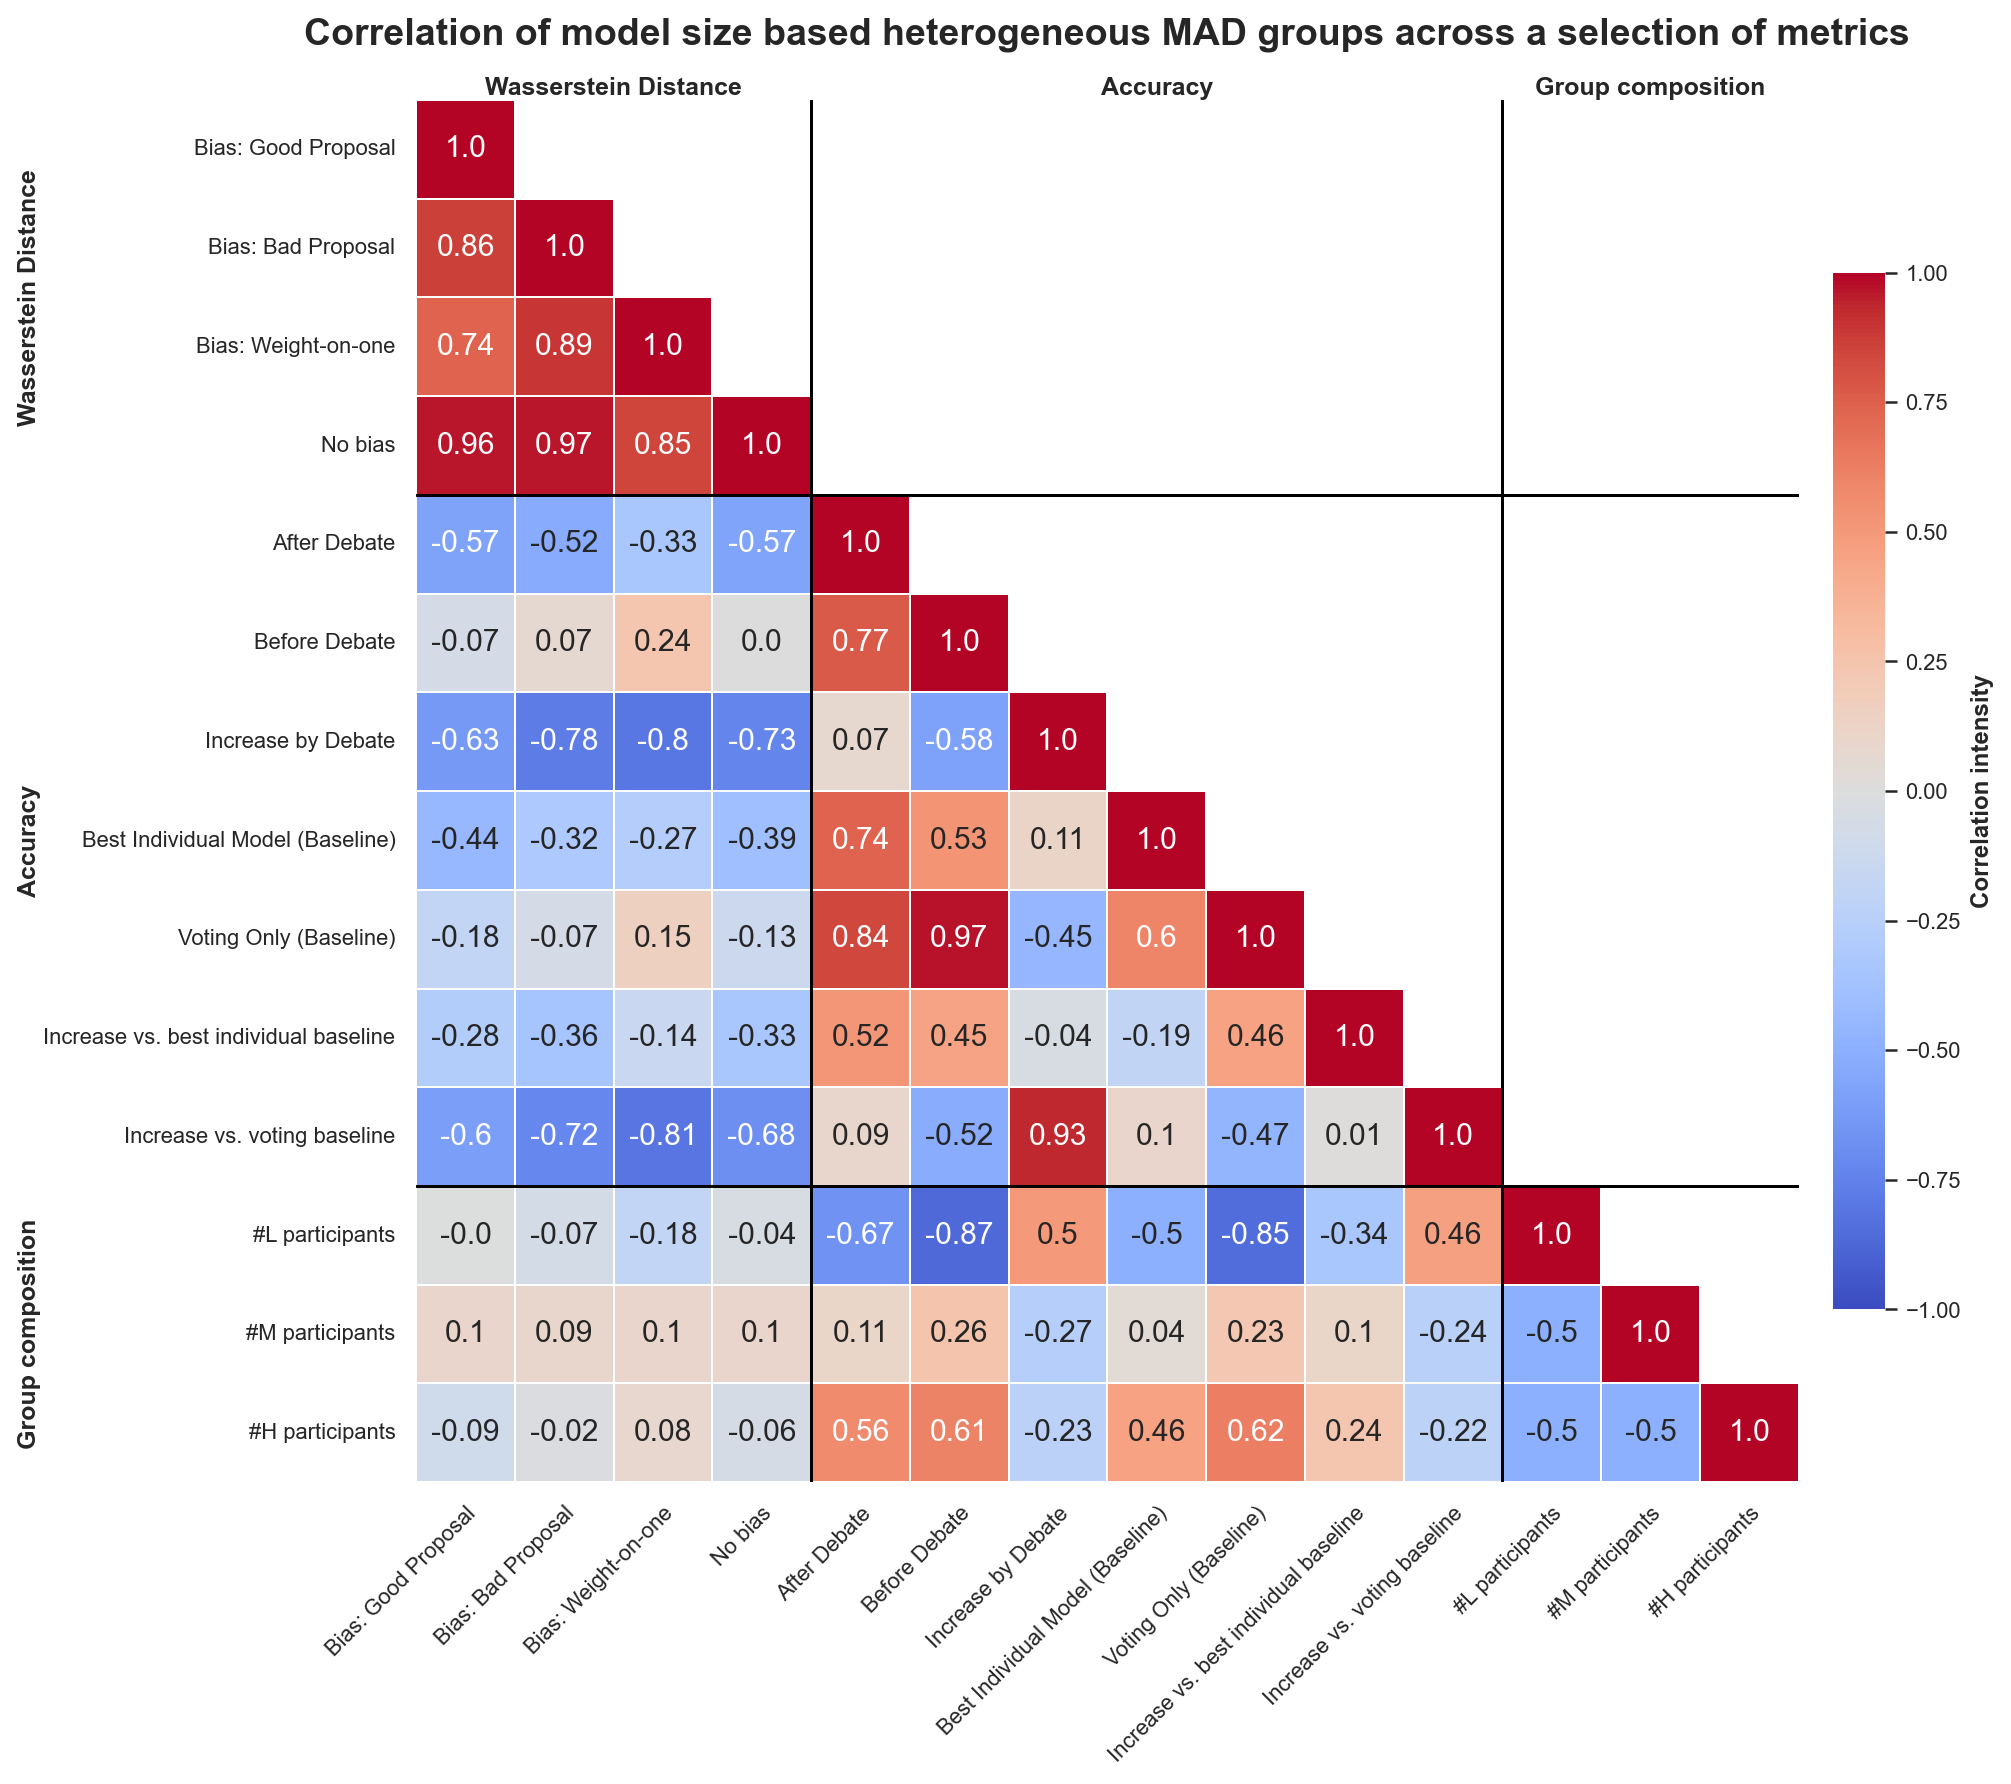

In [305]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# --- Convert and clean ---
df = mad_corr.to_pandas()
df.index = mad_corr.columns

# Remove requested variable
df = df.drop(
    index="accuracy_increase_percent",
    columns="accuracy_increase_percent",
    errors="ignore",
)

# --- Nice labels and grouping ---
groups = {
    "Wasserstein Distance": {
        "wd_bias_good proposals": "Bias: Good Proposal",
        "wd_bias_bad proposals": "Bias: Bad Proposal",
        "wd_bias_weight on one": "Bias: Weight-on-one",
        "wd_bias_False": "No bias",
    },
    "Accuracy": {
        "accuracy": "After Debate",
        "accuracy_before": "Before Debate",
        "accuracy_increase": "Increase by Debate",
        "accuracy_best_individual_baseline": "Best Individual Model (Baseline)",
        "accuracy_no_discussion_voting_same_calls_baseline": "Voting Only (Baseline)",
        "increase_from_individual": "Increase vs. best individual baseline",
        "increase_from_same_calls": "Increase vs. voting baseline",
    },
    "Group composition": {
        "number_of_L": "#L participants",
        "number_of_M": "#M participants",
        "number_of_H": "#H participants",
    },
}

ordered_cols = [
    col for group in groups.values() for col in group.keys() if col in df.columns
]

df = df.loc[ordered_cols, ordered_cols]

pretty_labels = [
    groups[group][col]
    for col in ordered_cols
    for group in groups
    if col in groups[group]
]

df.columns = pretty_labels
df.index = pretty_labels

# --- Triangle mask ---
mask = np.triu(np.ones_like(df, dtype=bool), k=1)

# --- Plot ---
sns.set_theme(style="white", context="paper", font_scale=1.0)

fig, ax = plt.subplots(figsize=(12, 10), dpi=180)

heatmap = sns.heatmap(
    df,  # correlation intensity: -0.6 and +0.6 look identical
    mask=mask,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.6,
    linecolor="white",
    annot=df.round(2),  # still show signed correlations
    fmt="",
    annot_kws={"size": 12},
    cbar_kws={
        "label": "Correlation intensity",
        "shrink": 0.75,
        "pad": 0.02,
    },
    ax=ax,
)

ax.set_title(
    "Correlation of model size based heterogeneous MAD groups across a selection of metrics",
    fontsize=15,
    fontweight="bold",
    pad=22,
)

ax.set_xlabel("")
ax.set_ylabel("")

ax.set_xticklabels(
    ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor"
)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# --- Group separators and labels ---
group_sizes = []
group_names = []

for group_name, mapping in groups.items():
    n = sum(col in ordered_cols for col in mapping)
    if n > 0:
        group_names.append(group_name)
        group_sizes.append(n)

boundaries = np.cumsum(group_sizes)

for b in boundaries[:-1]:
    ax.axhline(b, color="black", linewidth=1.2)
    ax.axvline(b, color="black", linewidth=1.2)

# Group labels on top
start = 0
for group_name, size in zip(group_names, group_sizes):
    center = start + size / 2
    ax.text(
        center,
        0,
        group_name,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )
    ax.text(
        -3.8,
        center,
        group_name,
        ha="right",
        va="center",
        fontsize=10,
        fontweight="bold",
        rotation=90,  # remove if you want horizontal text
    )
    start += size

plt.tight_layout()

register_materialization(
    "wasserstein_distance_correlation_heterogeneous_mad",
    fig,
    "Correlation of metrics of heterogeneous mad.",
    force=True,
)

In [249]:
import polars as pl
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr, spearmanr


ID_COLS = [
    "model_names",
    "group_constellation",
    "model_family",
    "sizes",
]

X_COL = [
    "wd_bias_good proposals",
    "wd_bias_bad proposals",
    "wd_bias_weight on one",
    "wd_bias_False",
]
Y_COL = "accuracy_increase"


def add_linear_residuals(
    df: pl.DataFrame,
    x_cols: list[str] = X_COL,
    y_col: str = Y_COL,
    residual_col: str = "accuracy_increase_residual",
    pred_col: str = "accuracy_increase_pred",
) -> tuple[pl.DataFrame, LinearRegression]:
    """
    Fits y ~ x and adds prediction + residual columns.
    Residual = observed y - predicted y.
    """

    fit_df = (
        df.select(x_cols + [y_col])
        .drop_nulls()
        .filter(pl.all_horizontal(pl.all().is_finite()))
    )

    X = fit_df[x_cols].to_numpy().reshape(-1, len(x_cols))
    y = fit_df[y_col].to_numpy()

    model = LinearRegression()
    model.fit(X, y)

    out = df.with_columns(
        (
            pl.lit(model.intercept_)
            + sum(
                pl.lit(model.coef_[i]) * pl.col(x_cols[i]) for i in range(len(x_cols))
            )
        ).alias(pred_col)
    ).with_columns((pl.col(y_col) - pl.col(pred_col)).alias(residual_col))
    return out, model


df_resid, model = add_linear_residuals(wasserstein_mad.__deepcopy__())

print("intercept:", model.intercept_)
print("slope:", model.coef_)

fit_df = (
    wasserstein_mad.select(X_COL + [Y_COL])
    .drop_nulls()
    .filter(pl.all_horizontal(pl.all().is_finite()))
)

print(
    "R²:",
    model.score(
        fit_df[X_COL].to_numpy().reshape(-1, len(X_COL)),
        fit_df[Y_COL].to_numpy(),
    ),
)


def residual_correlations(
    df: pl.DataFrame,
    candidate_cols: list[str],
    residual_col: str = "accuracy_increase_residual",
    min_n: int = 10,
) -> pl.DataFrame:
    rows = []

    for col in candidate_cols:
        tmp = (
            df.select([residual_col, col])
            .drop_nulls()
            .filter(pl.col(col).is_finite())
            .filter(pl.col(residual_col).is_finite().all())
        )

        if tmp.height < min_n:
            continue

        x = tmp[col].to_numpy()
        r = tmp[residual_col].to_numpy()

        pearson_corr, pearson_p = pearsonr(x, r)
        spearman_corr, spearman_p = spearmanr(x, r)

        rows.append(
            {
                "variable": col,
                "n": tmp.height,
                "pearson_corr_with_residual": pearson_corr,
                "pearson_p": pearson_p,
                "spearman_corr_with_residual": spearman_corr,
                "spearman_p": spearman_p,
                "abs_pearson": abs(pearson_corr),
                "abs_spearman": abs(spearman_corr),
            }
        )

    return pl.DataFrame(rows).sort("abs_pearson", descending=True)


candidate_cols = [
    "accuracy",
    "accuracy_before",
]

corrs = residual_correlations(df_resid, candidate_cols)
print(corrs)

intercept: 0.5600500403561535
slope: [ 0.07736968 -0.17323933 -0.15429848 -0.04793482]
R²: 0.6677660162548845
shape: (2, 8)
┌─────────────┬─────┬─────────────┬────────────┬────────────┬────────────┬────────────┬────────────┐
│ variable    ┆ n   ┆ pearson_cor ┆ pearson_p  ┆ spearman_c ┆ spearman_p ┆ abs_pearso ┆ abs_spearm │
│ ---         ┆ --- ┆ r_with_resi ┆ ---        ┆ orr_with_r ┆ ---        ┆ n          ┆ an         │
│ str         ┆ i64 ┆ dual        ┆ f64        ┆ esidual    ┆ f64        ┆ ---        ┆ ---        │
│             ┆     ┆ ---         ┆            ┆ ---        ┆            ┆ f64        ┆ f64        │
│             ┆     ┆ f64         ┆            ┆ f64        ┆            ┆            ┆            │
╞═════════════╪═════╪═════════════╪════════════╪════════════╪════════════╪════════════╪════════════╡
│ accuracy_be ┆ 81  ┆ -0.728408   ┆ 1.2927e-14 ┆ -0.667235  ┆ 1.0336e-11 ┆ 0.728408   ┆ 0.667235   │
│ fore        ┆     ┆             ┆            ┆            ┆       

Using:  ['wd_bias_good proposals', 'wd_bias_bad proposals', 'wd_bias_weight on one', 'wd_bias_False', 'used_input_tokens', 'used_output_tokens', 'amount_parsing_errors_after', 'amount_parsing_errors_before', 'call_cost_heuristic', 'used_input_tokens_best_individual_baseline', 'used_output_tokens_best_individual_baseline', 'call_cost_heuristic_best_individual_baseline', 'used_input_tokens_no_discussion_voting_same_calls_baseline', 'used_output_tokens_no_discussion_voting_same_calls_baseline', 'call_cost_heuristic_no_discussion_voting_same_calls_baseline', 'input_tokens_per_acc_pct', 'output_tokens_per_acc_pct', 'input_tokens_per_acc_pct_best_individual', 'output_tokens_per_acc_pct_best_individual', 'used_total_tokens', 'used_total_tokens_best_individual_baseline', 'used_total_tokens_no_discussion_voting_same_calls_baseline', 'number_of_L', 'number_of_M', 'number_of_H', 'group_constellation', 'model_family', 'accuracy_increase_percent', 'accuracy_before']

=== Decision Tree Rules ===

|-

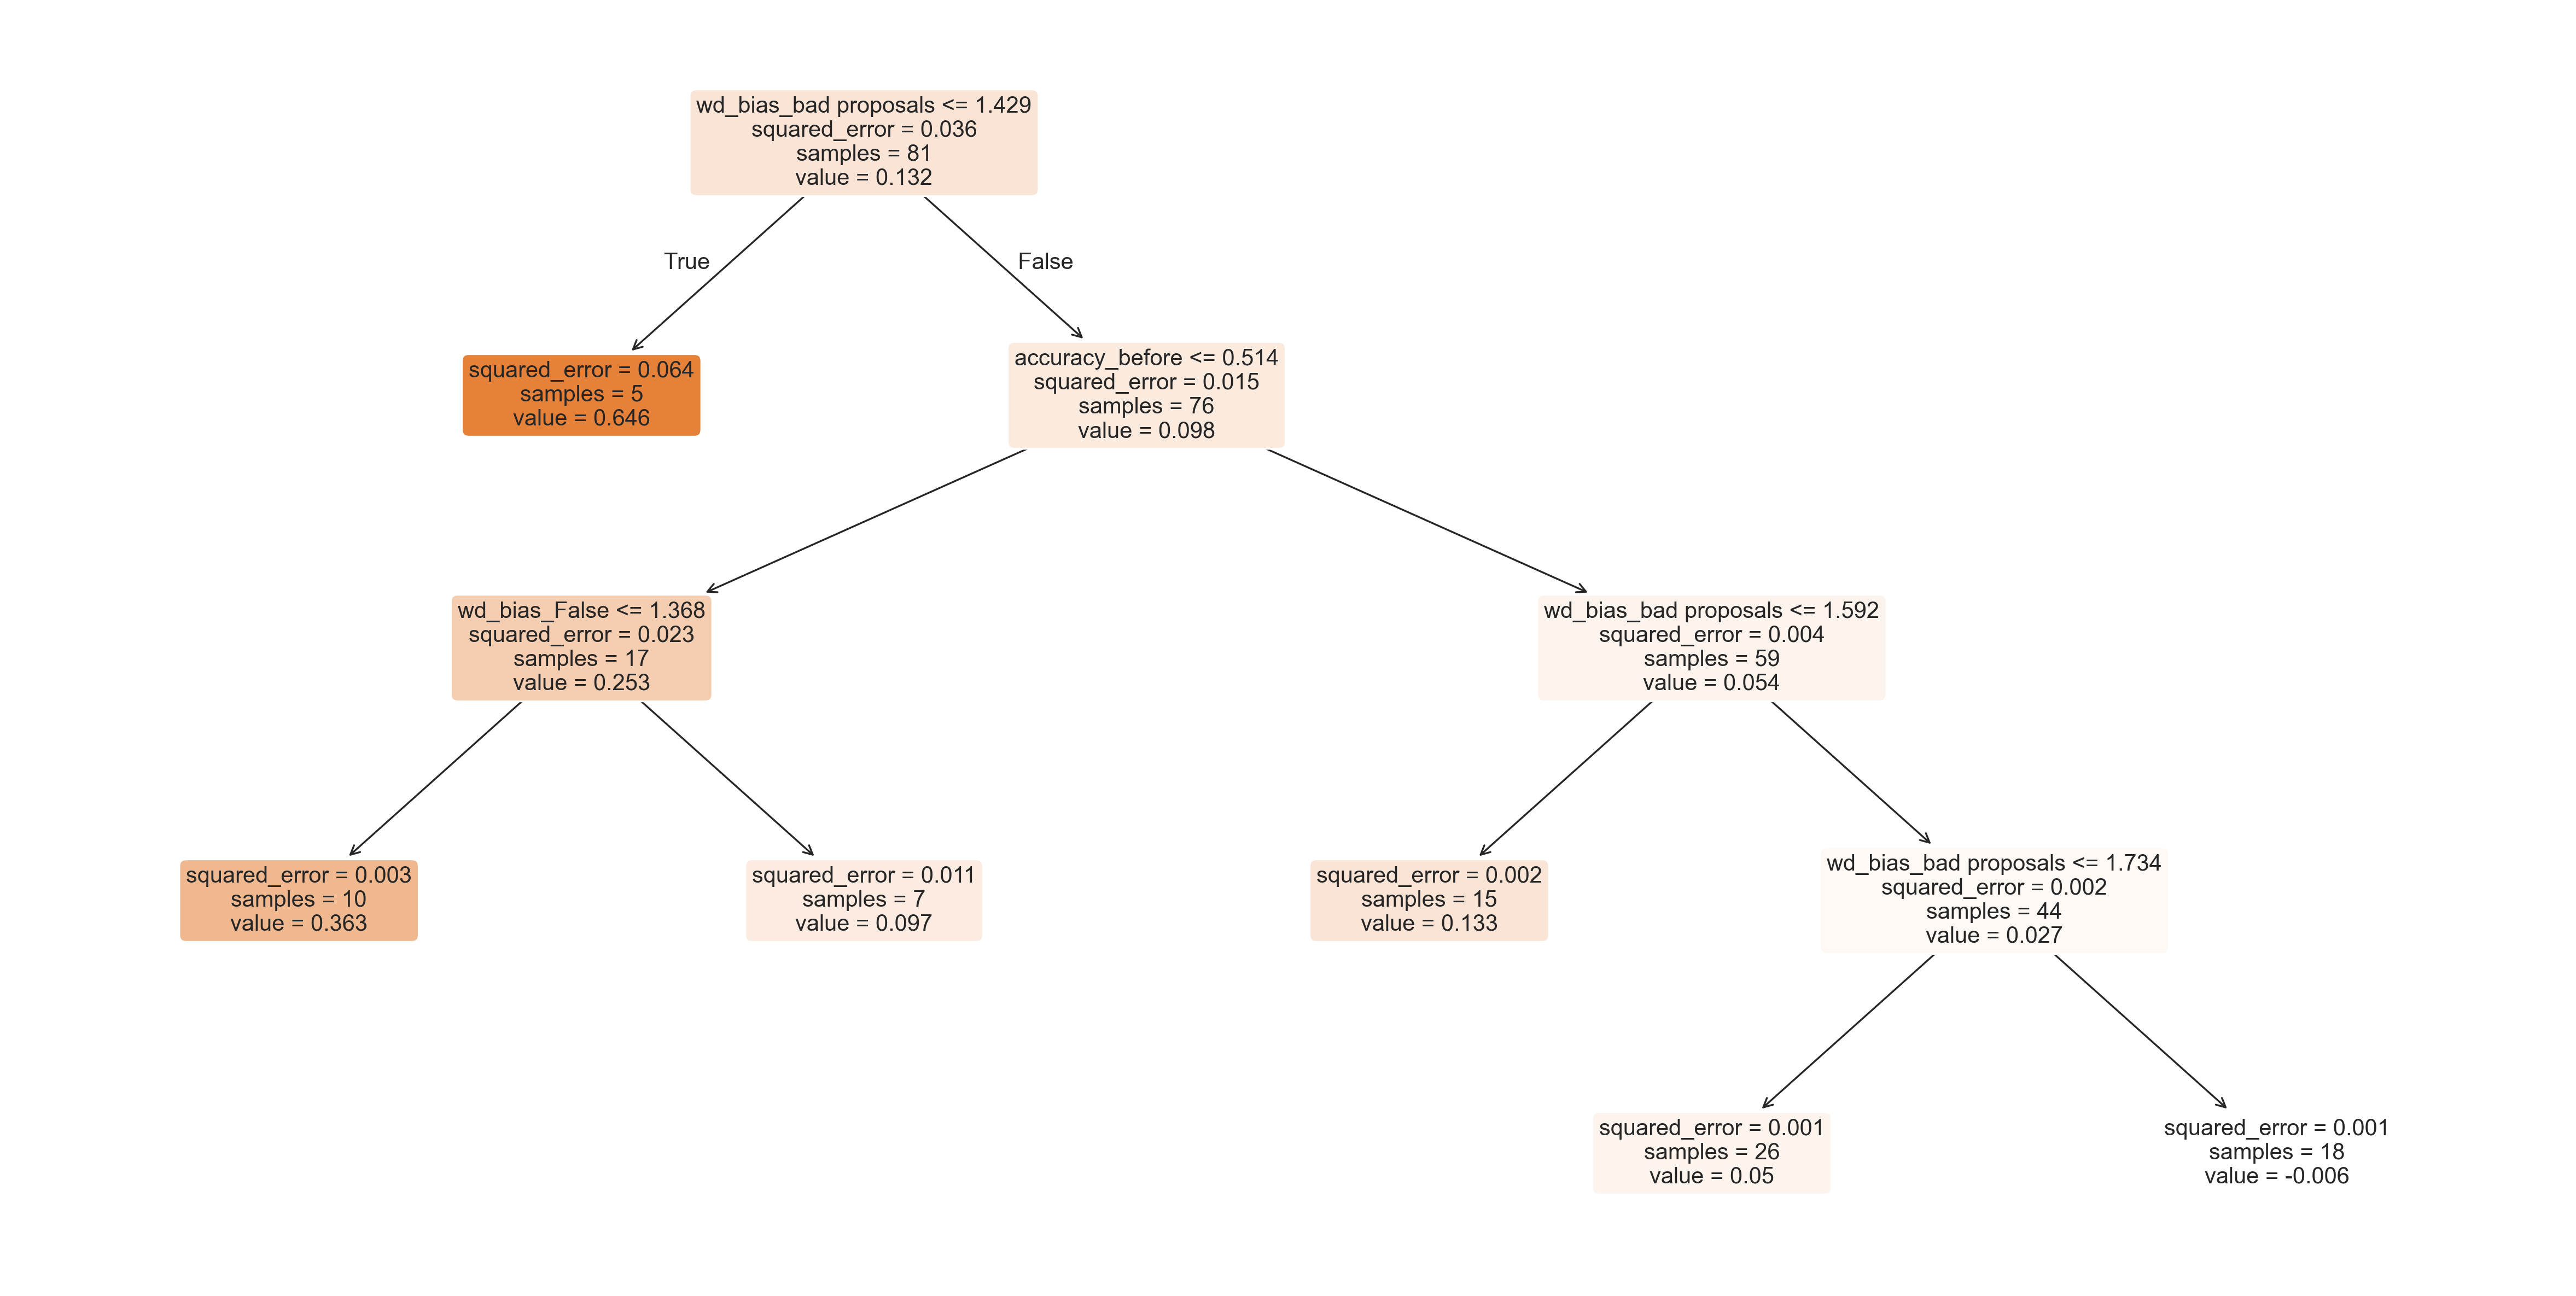


=== Names per leaf ===


Leaf 1
Names: ['LMH', 'LLH', 'LLH', 'LLM', 'LLM']
families: {5: 'Qwen3', 9: 'Qwen3.5', 22: 'Qwen3', 25: 'Qwen3.5', 55: 'Qwen3'}
Mean target: 0.6461231586113992

Leaf 5
Names: ['LLH', 'LHL', 'LHL', 'LML', 'HLL', 'MLL', 'LHL', 'HLL', 'LML', 'MLL']
families: {54: 'Ministral', 58: 'Qwen3.5', 60: 'Ministral', 62: 'Qwen3.5', 69: 'Qwen3.5', 71: 'Qwen3.5', 72: 'Qwen3', 74: 'Qwen3', 76: 'Qwen3', 77: 'Qwen3'}
Mean target: 0.36287893217163353

Leaf 6
Names: ['HLL', 'LML', 'LLM', 'MLL', 'LLL', 'LLL', 'LLL']
families: {65: 'Ministral', 67: 'Ministral', 70: 'Ministral', 75: 'Ministral', 78: 'Ministral', 79: 'Qwen3', 80: 'Qwen3.5'}
Mean target: 0.09696106222821364

Leaf 7
Names: ['MHH', 'MLH', 'HLM', 'MLH', 'MMH', 'LHH', 'HLH', 'LMH', 'LHM', 'HML', 'MHL', 'HHL', 'MLM', 'LMM', 'MML']
families: {0: 'Qwen3', 6: 'Qwen3', 7: 'Qwen3.5', 8: 'Qwen3.5', 10: 'Qwen3', 12: 'Qwen3.5', 13: 'Qwen3.5', 14: 'Qwen3.5', 19: 'Qwen3.5', 24: 'Qwen3.5', 26: 'Qwen3.5', 29: 'Qwen3.5', 33: 'Qwen3.5',

In [250]:
# ====== CONFIG ======
target_col = "accuracy_increase_percent"
name_col = plc.group_constellation
family_col = plc.model_family


df = wasserstein_mad.select(plselectors.numeric(), name_col, family_col).select(
    pl.exclude("^accuracy.*$", target_col, "run_id", "^increase.*$"),
    target_col,
    "accuracy_before",
)

print("Using: ", df.columns)

# ====== DATA PREP (Polars → Pandas) ======
X = df.drop(target_col, name_col, family_col).to_pandas()
y = df[target_col].to_pandas()
names = df.select(name_col).to_pandas()[name_col]
families = df.select(family_col).to_pandas()[family_col]

# ====== FIT INTERPRETABLE TREE ======
model = DecisionTreeRegressor(
    max_leaf_nodes=6,  # keep small for interpretability (3–5 recommended)
    random_state=42,
    min_samples_leaf=5,
)

model.fit(X, y)

# ====== PRINT RULES ======
print("\n=== Decision Tree Rules ===\n")
rules = export_text(model, feature_names=list(X.columns))
print(rules)

# ====== PLOT TREE ======
plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, filled=True, rounded=True, fontsize=10)
plt.show()

# ===== ASSIGN LEAVES =====

leaf_ids = model.apply(X)


# Attach everything into a dataframe
df_leaves = pd.DataFrame(
    {"leaf": leaf_ids, "name": names, "target": y, "family": families}
)
# ===== PRINT NAMES PER LEAF =====
print("\n=== Names per leaf ===\n")
for leaf, group in df_leaves.groupby("leaf"):
    print(f"\nLeaf {leaf}")
    print("Names:", group["name"].to_list())
    print("families:", group["family"].to_dict())
    print("Mean target:", group["target"].mean())

## Decision Scheme Analysis

### For One

In [68]:
one_case_data = mad_frame.filter(pl.col("run_id") == 190)

emp_matrix = calculate_empirical_decision_scheme(
    one_case_data,
    plc.parsed_individual_answers_before,
    plc.parsed_individual_answers_after,
    plc.answer_string,
    group_reply,
    comparer,
)

print("Empirical Decision Scheme:")
print(emp_matrix)

print("Comparison to other decision schemes")

for name, s in THEORETICAL_DECISION_SCHEMES.items():
    ll = log_likelihood_of_decision_scheme(emp_matrix, s, epsilon=0.05)
    print(f"{name}", ll)

Empirical Decision Scheme:
shape: (4, 3)
┌─────────┬───────────┬───────────────────────────┐
│ correct ┆ incorrect ┆ Correct Members Beginning │
│ ---     ┆ ---       ┆ ---                       │
│ i64     ┆ i64       ┆ u32                       │
╞═════════╪═══════════╪═══════════════════════════╡
│ 16      ┆ 191       ┆ 0                         │
│ 20      ┆ 32        ┆ 1                         │
│ 49      ┆ 11        ┆ 2                         │
│ 681     ┆ 0         ┆ 3                         │
└─────────┴───────────┴───────────────────────────┘
Comparison to other decision schemes
proportionality -46.47484746866315
majority_rule -76.59765008875573
truth_wins -111.93091783875298
truth_supported -76.59765008875573
unanimity -188.48633129708048
random_rule -580.0629042403277
incorrect_wins -2708.926097463553
minority_wins -2632.3706840052255


EPSILONS = [0.001, 0.01, 0.03, 0.05, 0.1, 0.3]
USED_COL = "accuracy"


def temporary(filtered_frame: pl.DataFrame):
    emp_matrix = calculate_empirical_decision_scheme(
        filtered_frame,
        plc.parsed_individual_answers_before,
        plc.parsed_individual_answers_after,
        plc.answer_string,
        group_reply,
        comparer,
    )

    filtered_frame = filtered_frame.with_columns(
        comparer(
            pl.col(plc.parsed_combined_answers_before),
            pl.col(plc.answer_string),
        ).alias("is_correct_before")
    )

    metadata = (
        filtered_frame.select(
            [
                name
                for name, is_constant in filtered_frame.select(pl.all().n_unique() == 1)
                .to_dicts()[0]
                .items()
                if is_constant
            ]
        )
        .unique()
        .to_dicts()[0]
    )

    for e in EPSILONS:
        for name, s in THEORETICAL_DECISION_SCHEMES.items():
            metadata[f"ll_{name}_{e}"] = log_likelihood_of_decision_scheme(
                emp_matrix, s, epsilon=e
            )
        metadata[f"best_fitting_ds_{e}"] = (
            max(
                filter(
                    lambda key: key.startswith("ll_") and key.endswith(f"{e}"), metadata
                ),
                key=lambda key: metadata[key],
            )
            .replace("ll_", "")
            .replace(f"{e}", "")
        )

    metadata[plc.accuracy] = filtered_frame[plc.is_correct].mean()
    metadata["accuracy_before"] = filtered_frame["is_correct_before"].mean()
    metadata["accuracy_increase"] = metadata[plc.accuracy] - metadata["accuracy_before"]
    metadata["accuracy_increase_percent"] = (
        metadata[plc.accuracy] / metadata["accuracy_before"]
    ) - 1

    return pl.DataFrame([metadata])


decision_scheme_mad = mad_frame.group_by("run_id").map_groups(temporary)

decision_scheme_mad = decision_scheme_mad.join(
    mad_performance,
    on=["model_family", "group_constellation", "accuracy"],
    how="inner",
    validate="1:1",
)
print(decision_scheme_mad.columns)
decision_scheme_mad = (
    decision_scheme_mad.sort(USED_COL)
    .select(
        pl.selectors.starts_with("best_fitting_ds_"),
        "model_family",
        "group_constellation",
        USED_COL,
        "accuracy_best_individual_baseline",
        "accuracy_no_discussion_voting_same_calls_baseline",
    )
    .sort(USED_COL, descending=True)
)

## Change in Order

In [290]:
import seaborn as sns
import matplotlib.pyplot as plt


df_plot = (
    decision_scheme_mad.with_columns(
        pl.col(USED_COL).clip(0, 1).mul(10).floor().truediv(10).alias("accuracy_bucket")
    )
    .sort("accuracy_bucket")
    .with_columns(
        pl.format(
            "{}–{}",
            pl.col("accuracy_bucket").round(1),
            (pl.col("accuracy_bucket") + 0.1).round(1),
        ).alias("accuracy_bucket_label")
    )
)

df_plot = (
    df_plot
    # .unpivot(
    #     index=[x for x in df_plot.columns if not x.startswith("best_fitting_ds_")],
    #     variable_name="epsilon",
    #     value_name="best_fitting_ds",
    # )
    # .with_columns(
    #     pl.col("epsilon").str.replace("best_fitting_ds_", "").cast(pl.Float64)
    # )
    .with_columns(
        pl.selectors.starts_with("best_fitting_ds")
        .str.replace("_", " ")
        .str.replace("proportionality", "Proportionality rule")
        .str.replace("truth wins_", "Truth wins rule")
        .str.replace("majority rule_", "Majority rule")
    )
)

df_plot = df_plot.to_pandas()

df_plot

,best_fitting_ds_0.001,best_fitting_ds_0.01,best_fitting_ds_0.03,best_fitting_ds_0.05,best_fitting_ds_0.1,best_fitting_ds_0.3,model_family,group_constellation,accuracy,accuracy_best_individual_baseline,accuracy_no_discussion_voting_same_calls_baseline,accuracy_bucket,accuracy_bucket_label
0,Proportionality rule,Proportionality rule,Proportionality rule,Proportionality rule,Proportionality rule,Proportionality rule,Qwen3.5,LLL,0.279,0.145,0.3372,0.2,0.2–0.3
1,Proportionality rule,Proportionality rule,Proportionality rule,Proportionality rule,Proportionality rule,Proportionality rule,Qwen3,LL,0.278,0.314,0.2894,0.2,0.2–0.3
2,Proportionality rule,Proportionality rule,Proportionality rule,Proportionality rule,Proportionality rule,Proportionality rule,Qwen3.5,LL,0.278,0.145,0.3201,0.2,0.2–0.3
3,Proportionality rule,Proportionality rule,Proportionality rule,Proportionality rule,Proportionality rule,Majority rule,Ministral,LLL,0.393,0.436,0.4281,0.3,0.3–0.4
4,Proportionality rule,Proportionality rule,Proportionality rule,Proportionality rule,Proportionality rule,Proportionality rule,Qwen3,LLL,0.304,0.314,0.2978,0.3,0.3–0.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,Proportionality rule,Proportionality rule,Proportionality rule,Proportionality rule,Proportionality rule,Truth wins rule,Qwen3.5,MMH,0.707,0.669,0.7274,0.7,0.7–0.8
104,Truth wins rule,Truth wins rule,Truth wins rule,Truth wins rule,Truth wins rule,Truth wins rule,Qwen3,LLH,0.706,0.733,0.4883,0.7,0.7–0.8
105,Proportionality rule,Proportionality rule,Proportionality rule,Proportionality rule,Proportionality rule,Truth wins rule,Qwen3.5,MHM,0.702,0.669,0.7274,0.7,0.7–0.8
106,Proportionality rule,Proportionality rule,Proportionality rule,Proportionality rule,Truth wins rule,Truth wins rule,Qwen3.5,HML,0.701,0.669,0.6954,0.7,0.7–0.8


In [285]:
USED_EPSILON = "0.05"

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/src/social_groups/analysis/notebook_assets.py:179: BetaWarning: Class `LocalFileCodeReference` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  dg.LocalFileCodeReference(
/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/src/social_groups/analysis/notebook_assets.py:184: BetaWarning: Class `LocalFileCodeReference` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  dg.LocalFileCodeReference(
/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/src/social_groups/analysis/notebook_assets.py:177: BetaWarning: Class `CodeReferencesMetadataValue` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  "dagster/code_references": dg.CodeReferencesMetadataValue(
/Users/philipp/Documents/St

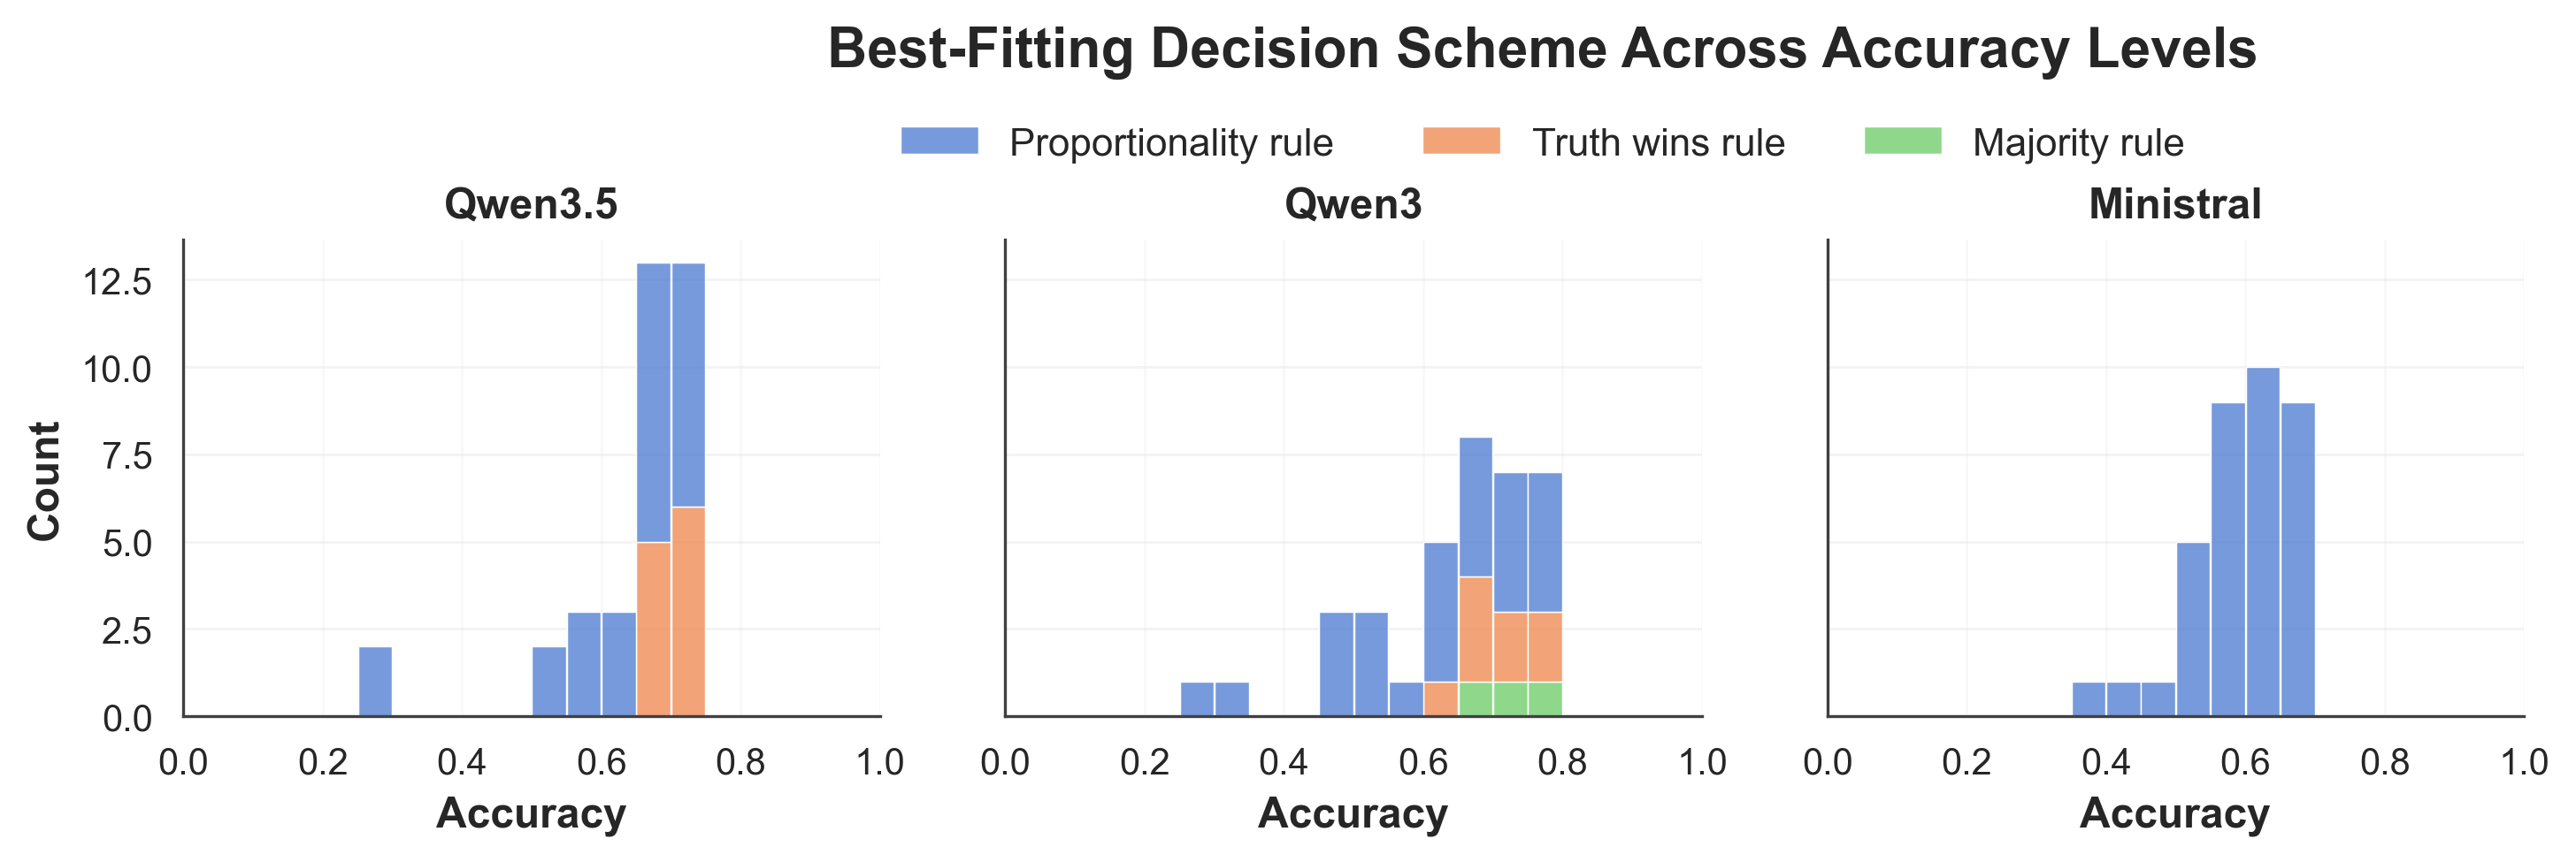

Wrote to:  /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/report/final_mad_baseline/best_fitting_decision_scheme_across_heterogeneous_mad.png


/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(


In [289]:
sns.set_theme(
    context="paper",
    style="whitegrid",
    font_scale=1.2,
    rc={
        "axes.edgecolor": "0.25",
        "axes.linewidth": 0.8,
        "grid.color": "0.90",
        "grid.linewidth": 0.7,
        "axes.titleweight": "bold",
        "figure.dpi": 300,
    },
)


g = sns.displot(
    data=df_plot,
    x=USED_COL,
    hue=f"best_fitting_ds_{USED_EPSILON}",
    col="model_family",
    multiple="stack",
    binwidth=0.05,
    binrange=(0, 1),
    shrink=0.98,
    palette="muted",
    height=3.1,
    aspect=1.05,
    edgecolor="white",
    linewidth=0.35,
    legend=True,
)

g.set_axis_labels("Accuracy", "Number of samples")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.grid(True, axis="y", alpha=0.45)
    ax.grid(True, axis="x", alpha=0.25)
    ax.set_xlim(0, 1)
    ax.tick_params(axis="both", labelsize=10)
    ax.set_xlabel("Accuracy")
    ax.set_ylabel("Count")

g.figure.subplots_adjust(top=0.72, bottom=0.14, wspace=0.18)

g.figure.suptitle(
    "Best-Fitting Decision Scheme Across Accuracy Levels",
    fontsize=15,
    fontweight="bold",
    y=0.98,
)

# Move legend below title, centered, horizontal
sns.move_legend(
    g,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.90),
    ncol=3,
    title="",
    frameon=False,
)

plt.show()

register_materialization(
    "best_fitting_decision_scheme_across_heterogeneous_mad",
    g.figure,
    f"Amount of groups that have a certain decision scheme as best fitting for their debate behavior based on log likelihood and Epsilon of {USED_EPSILON}",
    force=True,
)

In [304]:
decision_scheme_correlation = (
    decision_scheme_mad.with_columns(
        ind=(pl.col("accuracy") - pl.col("accuracy_best_individual_baseline")),
        vot=(
            pl.col("accuracy")
            - pl.col("accuracy_no_discussion_voting_same_calls_baseline")
        ),
    )
    .group_by(f"best_fitting_ds_{USED_EPSILON}")
    .agg(
        (pl.col("ind")).mean().alias("ind"),
        pl.col("ind").std().alias("ind_std"),
        pl.col("vot").mean(),
        pl.col("vot").std().alias("vot_std"),
    )
    .with_columns(pl.selectors.numeric().round(2))
    .select(
        pl.col(f"best_fitting_ds_{USED_EPSILON}")
        .alias("Decision Scheme")
        .str.replace("proportionality_", "Proportionality")
        .str.replace("truth_wins_", "Truth wins")
        .str.replace("majority_rule_", "Majority"),
        (
            pl.when(pl.col("ind") > 0).then(pl.lit(" ")).otherwise(pl.lit(""))
            + pl.col("ind").cast(pl.String)
            + pl.lit(" (")
            + pl.col("ind_std").cast(pl.String)
            + pl.lit(")")
        ).alias("Improvement vs. individual model baseline (Mean (Std))"),
        (
            pl.when(pl.col("vot") > 0).then(pl.lit(" ")).otherwise(pl.lit(""))
            + pl.col("vot").cast(pl.String)
            + pl.lit(" (")
            + pl.col("vot_std").cast(pl.String)
            + pl.lit(")")
        ).alias("Improvement vs. eq. calls voting baseline (Mean (Std))"),
    )
)


register_materialization(
    "decisionscheme_correlation_with_improvement_over_baselines",
    decision_scheme_correlation,
    "decisionscheme_correlation_with_improvement_over_baselines",  force=True
)
decision_scheme_correlation

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/src/social_groups/analysis/notebook_assets.py:179: BetaWarning: Class `LocalFileCodeReference` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  dg.LocalFileCodeReference(
/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/src/social_groups/analysis/notebook_assets.py:184: BetaWarning: Class `LocalFileCodeReference` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  dg.LocalFileCodeReference(
/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/src/social_groups/analysis/notebook_assets.py:177: BetaWarning: Class `CodeReferencesMetadataValue` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  "dagster/code_references": dg.CodeReferencesMetadataValue(
/Users/philipp/Documents/St

Wrote to:  /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/report/final_mad_baseline/decisionscheme_correlation_with_improvement_over_baselines.tex


/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(


Decision Scheme,Improvement vs. individual model baseline (Mean (Std)),Improvement vs. eq. calls voting baseline (Mean (Std))
str,str,str
"""Majority""","""-0.01 (0.04)""",""" 0.01 (0.01)"""
"""Truth wins""",""" 0.03 (0.03)""",""" 0.06 (0.08)"""
"""Proportionality""","""-0.04 (0.07)""","""-0.01 (0.04)"""


In [ ]:
df_with_composition = mad_performance.with_columns(
    pl.col("group_constellation")
    .map_elements(lambda s: "".join(sorted(s)), return_dtype=pl.String)
    .alias("group_composition")
)

In [ ]:
order_effects = df_with_composition.group_by(["model_family", "group_composition"]).agg(
    [
        pl.mean("accuracy").alias("mean_accuracy"),
        pl.std("accuracy").alias("std_accuracy"),
        pl.len().alias("n"),
        pl.mean("accuracy_best_individual_baseline").alias("mean_best_individual"),
        pl.std("accuracy_best_individual_baseline").alias("std_best_individual"),
        pl.mean("accuracy_no_discussion_voting_same_calls_baseline").alias(
            "mean_no_discussion"
        ),
        pl.std("accuracy_no_discussion_voting_same_calls_baseline").alias(
            "std_no_discussion"
        ),
    ]
)


order_effects = (
    order_effects.group_by("group_composition")
    .agg(
        pl.col("std_accuracy").mean(),
        pl.col("std_no_discussion").mean(),
        pl.col("std_best_individual").mean(),
    )
    .sort("std_accuracy", descending=True)
)

print("\n=== order effects within same composition ===")
order_effects

In [ ]:
permutation_spread = (
    order_effects.group_by(["model_family", "group_composition"])
    .agg(
        [
            pl.max("accuracy").alias("best_perm"),
            pl.min("accuracy").alias("worst_perm"),
            (pl.max("accuracy") - pl.min("accuracy")).alias("spread"),
            pl.std("accuracy").alias("perm_std"),
            pl.len().alias("num_permutations"),
        ]
    )
    .sort("spread", descending=True)
)

print("\n=== PERMUTATION SPREAD ===")
permutation_spread

In [ ]:
# ============================================================
# 4. Which POSITION matters?
#
#    Example questions:
#      - Is H strongest in position 1?
#      - Is M bad in the middle?
#
#    We explode each string into positional columns.
# ============================================================

max_len = df_with_composition.select(
    pl.col("group_constellation").str.len_chars().max()
).item()

# Create position columns
for i in range(max_len):
    df_with_composition = df_with_composition.with_columns(
        pl.col("group_constellation").str.slice(i, 1).alias(f"pos_{i + 1}")
    )

# Analyze position effects
position_effects = (
    df_with_composition.unpivot(
        index=["model_family", "accuracy", "best_individual_performance"],
        on=[f"pos_{i + 1}" for i in range(max_len)],
        variable_name="position",
        value_name="member",
    )
    .group_by(["model_family", "position", "member"])
    .agg(
        [
            pl.mean("accuracy").alias("mean_accuracy"),
            pl.std("accuracy").alias("std_accuracy"),
            pl.len().alias("n"),
        ]
    )
    .sort(
        ["model_family", "position", "mean_accuracy"], descending=[False, False, True]
    )
)

print("\n=== POSITION EFFECTS ===")
print(position_effects)


# ============================================================
# 5. FAMILY DIFFERENCES
#
#    Compare families overall.
# ============================================================

family_summary = (
    df_with_composition.group_by("model_family")
    .agg(
        [
            pl.mean("accuracy").alias("mean_accuracy"),
            pl.std("accuracy").alias("std_accuracy"),
            pl.mean("best_individual_performance").alias("mean_best_individual"),
            pl.len().alias("n"),
        ]
    )
    .sort("mean_accuracy", descending=True)
)

print("\n=== FAMILY SUMMARY ===")
print(family_summary)


# ============================================================
# 6. FAMILY x COMPOSITION interaction
#
#    Which family handles which group_compositions best?
# ============================================================

family_group_composition = (
    df_with_composition.group_by(["model_family", "group_composition"])
    .agg(
        [
            pl.mean("accuracy").alias("mean_accuracy"),
            pl.std("accuracy").alias("std_accuracy"),
            pl.len().alias("n"),
        ]
    )
    .sort(["group_composition", "mean_accuracy"], descending=[False, True])
)

print("\n=== FAMILY x COMPOSITION ===")
print(family_group_composition)


# ============================================================
# 7. Pairwise permutation comparisons
#
#    Directly compare permutations of same group_composition.
#
#    Example:
#      HML - HLM = +0.03
# ============================================================

pairwise_rows = []

for (family, comp), group in order_effects.group_by(
    ["model_family", "group_composition"]
):
    rows = group.to_dicts()

    for a, b in combinations(rows, 2):
        diff = a["mean_accuracy"] - b["mean_accuracy"]

        pairwise_rows.append(
            {
                "model_family": family,
                "group_composition": comp,
                "perm_a": a["group_constellation"],
                "perm_b": b["group_constellation"],
                "accuracy_diff": diff,
                "abs_diff": abs(diff),
            }
        )

pairwise_df = pl.DataFrame(pairwise_rows).sort("abs_diff", descending=True)

print("\n=== PAIRWISE PERMUTATION DIFFERENCES ===")
print(pairwise_df)


# ============================================================
# 8. Optional:
#    Simple "does order matter?" score
#
#    Ratio:
#      variation BETWEEN permutations
#      --------------------------------
#      total variation
# ============================================================

overall_std = df_with_composition.select(pl.std("accuracy")).item()

spread_score = permutation_spread.with_columns(
    (pl.col("spread") / overall_std).alias("normalized_order_effect")
).sort("normalized_order_effect", descending=True)

print("\n=== NORMALIZED ORDER EFFECT ===")
print(spread_score)

In [ ]:
register_materialization(USED_NAME, SOME_DATA, SOME_DESCRIPTION)

## OLD comparison for heterogeneous:

In [ ]:
het_mad_comparison = (
    heterogeneous_mad.with_columns(
        params=pl.col("model_names")
        .list.eval(parse_parameters(pl.element()))
        .alias("params")
    )
    .select(
        [
            "model_family",
            "group_constellation",
            "accuracy",
            "accuracy_best_individual_baseline",
            "accuracy_no_discussion_voting_same_calls_baseline",
            "params",
        ]
    )
    .with_columns(
        increase_from_best_individual_baseline=(
            pl.col("accuracy") - pl.col("accuracy_best_individual_baseline")
        ),
        increase_from_no_discussion_voting_same_calls_baseline=(
            pl.col("accuracy")
            - pl.col("accuracy_no_discussion_voting_same_calls_baseline")
        ),
    )
    .sort("increase_from_best_individual_baseline")
)

cols = het_mad_comparison.select(pl.selectors.starts_with("accuracy")).columns
best_method_per_group = (
    het_mad_comparison.with_columns(
        pl.when(pl.col(cols[0]) == pl.max_horizontal(pl.col(cols)))
        .then(pl.lit(cols[0]))
        .when(pl.col(cols[1]) == pl.max_horizontal(pl.col(cols)))
        .then(pl.lit(cols[1]))
        .when(pl.col(cols[2]) == pl.max_horizontal(pl.col(cols)))
        .then(pl.lit(cols[2]))
        .alias("best_method")
        .str.replace("accuracy_", "")
        .str.replace("_baseline", "")
    )
    .group_by("group_constellation")
    .agg(
        pl.col("best_method").value_counts(sort=True),
        # pl.col("params").implode().list.eval(pl.element().list.std()).list.mean().alias("average_std_dev"),
        # pl.col("params").implode().list.eval(pl.element().list.mean()).list.mean().alias("average_params"),
    )
    .with_columns(
        pl.col("group_constellation").str.count_matches(s).alias(f"{s}count")
        for s in "LMH"
    )
    .sort("Lcount", "Mcount", "Hcount", descending=True)
)

In [ ]:
import polars as pl

methods_long = (
    best_method_per_group.explode("best_method")
    .with_columns(
        [
            pl.col("best_method").struct.field("best_method").alias("method"),
            pl.col("best_method").struct.field("count").alias("method_count"),
        ]
    )
    .drop("best_method")
)

winner_df = (
    methods_long.sort(["group_constellation", "method_count"], descending=[False, True])
    .group_by("group_constellation")
    .agg(
        [
            pl.col("method").first().alias("winner"),
            pl.col("method_count").first().alias("winner_count"),
            pl.col("method_count").sum().alias("total_count"),
            pl.len().alias("num_methods_observed"),
        ]
    )
    .with_columns(
        [(pl.col("winner_count") / pl.col("total_count")).alias("confidence")]
    )
)

feature_df = (
    winner_df.with_columns(
        [
            pl.col("group_constellation").str.strip_chars('"').alias("s"),
        ]
    )
    .with_columns(
        [
            pl.col("s").str.len_chars().alias("n"),
            pl.col("s").str.count_matches("L").alias("Lcount"),
            pl.col("s").str.count_matches("M").alias("Mcount"),
            pl.col("s").str.count_matches("H").alias("Hcount"),
            pl.col("s").str.slice(0, 1).alias("first_symbol"),
            pl.col("s").str.slice(-1, 1).alias("last_symbol"),
            (pl.col("s").str.slice(0, 1) == "L").alias("first_is_L"),
            (pl.col("s").str.slice(0, 1) == "M").alias("first_is_M"),
            (pl.col("s").str.slice(0, 1) == "H").alias("first_is_H"),
            (pl.col("s").str.slice(-1, 1) == "L").alias("last_is_L"),
            (pl.col("s").str.slice(-1, 1) == "M").alias("last_is_M"),
            (pl.col("s").str.slice(-1, 1) == "H").alias("last_is_H"),
        ]
    )
    .with_columns(
        [
            (pl.col("Lcount") / pl.col("n")).alias("Lshare"),
            (pl.col("Mcount") / pl.col("n")).alias("Mshare"),
            (pl.col("Hcount") / pl.col("n")).alias("Hshare"),
            (pl.col("Hcount") >= 2).alias("H_majority"),
            (pl.col("Mcount") >= 2).alias("M_majority"),
            (pl.col("Lcount") >= 2).alias("L_majority"),
            ((pl.col("Hcount") >= 2) & (pl.col("Lcount") == 0)).alias(
                "pure_high_or_medium_high"
            ),
            ((pl.col("Hcount") >= 2) & (pl.col("Lcount") >= 1)).alias("high_with_low"),
            ((pl.col("Hcount") == 0) & (pl.col("Mcount") >= 2)).alias(
                "medium_only_majority"
            ),
        ]
    )
)

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

model_df = feature_df.select(
    [
        "winner",
        "n",
        "Lcount",
        "Mcount",
        "Hcount",
        "first_symbol",
        "last_symbol",
        # "winner",
        # "n",
        # "Lcount",
        # "Mcount",
        # "Hcount",
        # "Lshare",
        # "Mshare",
        # "Hshare",
        # "first_symbol",
        # "last_symbol",
        # "first_is_L",
        # "first_is_M",
        # "first_is_H",
        # "last_is_L",
        # "last_is_M",
        # "last_is_H",
        "H_majority",
        "M_majority",
        "L_majority",
    ]
)

boolean_cols = model_df.select(pl.selectors.boolean()).columns

model_df = model_df.to_pandas()

X = model_df.drop(columns=["winner"])
y = model_df["winner"]

categorical_features = ["first_symbol", "last_symbol"]
numeric_features = [c for c in X.columns if c not in categorical_features]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop=None), categorical_features),
        ("num", "passthrough", numeric_features),
    ]
)

tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=1, random_state=42)

clf = Pipeline([("preprocess", preprocess), ("tree", tree)])

clf.fit(X, y)

pred = clf.predict(X)

print("In-sample accuracy:", accuracy_score(y, pred))
print(classification_report(y, pred))

# Get fitted components
fitted_preprocess = clf.named_steps["preprocess"]
fitted_tree = clf.named_steps["tree"]

cat_names = fitted_preprocess.named_transformers_["cat"].get_feature_names_out(
    categorical_features
)
feature_names = list(cat_names) + numeric_features

# plt.figure(figsize=(22, 10))
# plot_tree(
#     fitted_tree,
#     feature_names=feature_names,
#     class_names=fitted_tree.classes_,
#     filled=False,
#     rounded=True,
#     fontsize=9,
#     impurity=False,
# )
# plt.title("Shallow decision tree for winning method")
# plt.show()

replace_patterns = {
    "H_majority <= 0": "No H majority",
    "H_majority >  0": "Has H majority",
    "M_majority <= 0": "No M majority",
    "M_majority >  0": "Has M majority",
    "L_majority <= 0": "No L majority",
    "L_majority >  0": "Has L majority",
    "last_symbol_H <= 0": "Last is not H",
    "last_symbol_H >  0": "Last is H",
    "last_symbol_M <= 0": "Last is not M",
    "last_symbol_M >  0": "Last is M",
    "last_symbol_L <= 0": "Last is not L",
    "last_symbol_L >  0": "Last is L",
    "first_symbol_H <= 0": "First is not H",
    "first_symbol_H >  0": "First is H",
    "first_symbol_M <= 0": "First is not M",
    "first_symbol_M >  0": "First is M",
    "first_symbol_L <= 0": "First is not L",
    "first_symbol_L >  0": "First is L",
    "Lcount <= 0": "No L members",
    "Lcount >  0": "At least one L member",
    "Mcount <= 0": "No M members",
    "Mcount >  0": "At least one M member",
    "Hcount <= 0": "No H members",
    "Hcount >  0": "At least one H member",
    "Lcount <= 1": "At most one L member",
    "Lcount >  1": "At least two L members",
    "Mcount <= 1": "At most one M member",
    "Mcount >  1": "At least two M members",
    "Hcount <= 1": "At most one H member",
    "Hcount >  1": "At least two H members",
    "Lcount <= 2": "At most two L members",
    "Lcount >  2": "At least three L members",
    "Mcount <= 2": "At most two M members",
    "Mcount >  2": "At least three M members",
    "Hcount <= 2": "At most two H members",
    "Hcount >  2": "At least three H members",
    "n <= 2": "Pair constellation",
    "n >  2": "Triple constellation",
    "n <= 1": "Single-member constellation",
    "n >  1": "Multi-member constellation",
    "class: no_discussion_voting_same_calls": "Choose voting",
    "class: best_individual": "Choose Single Best Model",
    "class: accuracy": "Choose MAD",
}

rules = export_text(
    fitted_tree, feature_names=feature_names, decimals=0, show_weights=False
)
for a, b in replace_patterns.items():
    rules = rules.replace(a, b)

print(rules)

In [ ]:
just_bad = defaultdict(set)
better_than_voting_baseline = defaultdict(set)
better_than_single_baseline = defaultdict(set)
just_good = defaultdict(set)

for (
    family,
    constellation,
    _,
    _,
    _,
    increase_from_best_individual_baseline,
    increase_from_no_discussion_voting_same_calls_baseline,
) in het_mad_comparison.iter_rows():
    case = (
        increase_from_best_individual_baseline > 0.01,
        increase_from_no_discussion_voting_same_calls_baseline > 0.01,
    )
    match case:
        case (True, True):
            group = just_good
        case (False, True):
            group = better_than_voting_baseline
        case (True, False):
            group = better_than_single_baseline
        case (False, False):
            group = just_bad
        case _:
            raise RuntimeError()

    group[constellation].add(family)


def print_mapping(title: str, mapping: dict[str, set[str]]) -> None:
    print(f"\n{title}")
    print("-" * len(title))

    if not mapping:
        print("  (empty)")
        return

    for key in sorted(mapping):
        values = sorted(mapping[key])
        print(f"{key}: {', '.join(values)}")


print_mapping("Just Bad", just_bad)
print_mapping("Better Than Voting", better_than_voting_baseline)
print_mapping("Better Than Single Baseline", better_than_single_baseline)
print_mapping("Just Good", just_good)

In [ ]:
df = het_mad_comparison.drop("params")

metric_cols = [
    c for c in df.columns if c not in ["model_family", "group_constellation"]
]

model_families = df["model_family"].unique().sort().to_list()

wide = (
    df.unpivot(
        index=["group_constellation", "model_family"],
        on=metric_cols,
        variable_name="metric",
        value_name="value",
    )
    .with_columns(
        pl.concat_str(["metric", "model_family"], separator="__").alias("metric_model")
    )
    .pivot(
        index="group_constellation",
        columns="metric_model",
        values="value",
        aggregate_function="first",
    )
)

ordered_cols = ["group_constellation"] + [
    f"{metric}__{model}"
    for metric in metric_cols
    for model in model_families
    if f"{metric}__{model}" in wide.columns
]

wide = wide.select(ordered_cols)

wide.filter(pl.all_horizontal(pl.selectors.numeric().ge(-0.05)))

In [ ]:
no_constellation_better_than_baseline = enhanced_plot_df

better_in_voting = set(
    no_constellation_better_than_baseline.filter(
        pl.col("accuracy_no_discussion_voting_same_calls_baseline")
        > pl.col("accuracy_best_individual_baseline")
    )["group_composition"]
    .unique()
    .sort()
    .to_list()
)

better_alone = set(
    no_constellation_better_than_baseline.filter(
        pl.col("accuracy_no_discussion_voting_same_calls_baseline")
        < pl.col("accuracy_best_individual_baseline")
    )["group_composition"]
    .unique()
    .sort()
    .to_list()
)

print(better_in_voting)
print(better_alone)
print("in all families Better in voting")
print(better_in_voting - (better_alone))
print("in all families Better alone")
print(better_alone - (better_in_voting))

print("depends on family")
print(better_in_voting & better_alone)